# Telecom Customer Churn — Model Development

## Objective

The objective of this notebook is to develop and evaluate churn prediction
models using the prepared customer dataset.

The modelling process will first establish a baseline using the available
customer features and then evaluate the contribution of the engineered
behavioural and temporal features.

The focus is not only on predictive performance, but also on determining
whether the behavioural representation developed during data preparation
provides meaningful additional information for churn prediction.

## Load Prepared Dataset

The prepared dataset generated in the previous notebook is loaded as the
input for model development.

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

# Define the path to the prepared dataset.
DATA_PATH = (
    Path("../data/processed")
    / "telecom_churn_prepared.csv"
)

# Load the prepared customer-level dataset.
df = pd.read_csv(DATA_PATH)

# Confirm successful loading and dataset dimensions.
print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset path: E:\Churn Prediction\data\processed\telecom_churn_prepared.csv
Rows    : 69999
Columns : 191


## Separate Features and Target

The target variable `churn_probability` represents whether the customer
churned.

It is separated from the remaining columns so that the models use only
customer information as input and learn to predict the target.

In [7]:
# Define the target variable used for supervised learning.
target = "churn_probability"

# Separate the target from the customer input features.
X = df.drop(columns=[target])
y = df[target]

# Confirm the resulting feature matrix and target vector dimensions.
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape        : {y.shape}")

# Display the target class distribution before splitting the data.
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (69999, 190)
Target shape        : (69999,)

Target distribution:
churn_probability
0    62867
1     7132
Name: count, dtype: int64


## Remove Customer Identifier

The `id` column uniquely identifies each customer but does not represent
customer behaviour or a predictive business characteristic.

It is therefore retained only for customer-level reference and excluded from
the model input features.

In [8]:
# Remove the customer identifier from the model feature matrix.
X = X.drop(columns=["id"])

# Confirm the final feature matrix dimensions before data splitting.
print(f"Feature matrix shape after removing ID: {X.shape}")
print(f"Target shape                        : {y.shape}")

Feature matrix shape after removing ID: (69999, 189)
Target shape                        : (69999,)


## Train-Validation Split

The prepared dataset is divided into training and validation sets before model
development.

The training set is used to learn model parameters, while the validation set
is kept unseen during training and is used to evaluate how well the model
generalizes to new customers.

A stratified split is used so that the proportion of churn and non-churn
customers remains approximately consistent across both sets.

In [9]:
from sklearn.model_selection import train_test_split

# Create an 80:20 stratified split for model training and validation.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Confirm the resulting dataset dimensions.
print("Training set:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nValidation set:")
print(f"X_valid: {X_valid.shape}")
print(f"y_valid: {y_valid.shape}")

# Verify that the target distribution is preserved after stratification.
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True))

Training set:
X_train: (55999, 189)
y_train: (55999,)

Validation set:
X_valid: (14000, 189)
y_valid: (14000,)

Training target distribution:
churn_probability
0    0.898105
1    0.101895
Name: proportion, dtype: float64

Validation target distribution:
churn_probability
0    0.898143
1    0.101857
Name: proportion, dtype: float64


## Baseline Random Forest

A Random Forest classifier is trained as the first baseline model.

The baseline establishes the predictive performance that can be achieved using
the prepared customer features before specifically evaluating the contribution
of the engineered behavioural deterioration features.

Class weighting is enabled to account for the imbalance between churn and
non-churn customers.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [11]:
# Initialize the baseline Random Forest classifier.
baseline_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the baseline model using only the training data.
baseline_rf.fit(X_train, y_train)

print("Baseline Random Forest training completed.")

Baseline Random Forest training completed.


In [12]:
# Generate churn predictions and churn probabilities for unseen validation data.
y_valid_pred = baseline_rf.predict(X_valid)
y_valid_proba = baseline_rf.predict_proba(X_valid)[:, 1]

print("Validation predictions generated.")

Validation predictions generated.


## Baseline Model Evaluation

The baseline model is evaluated on the validation set using multiple metrics.

Because churn is an imbalanced classification problem, accuracy alone is not
sufficient. ROC-AUC and PR-AUC are used to evaluate ranking performance, while
precision, recall and F1-score provide class-level performance for churn
detection.

The confusion matrix is also examined to understand the types of prediction
errors made by the model.

In [13]:
# Calculate threshold-independent ranking metrics.
roc_auc = roc_auc_score(y_valid, y_valid_proba)
pr_auc = average_precision_score(y_valid, y_valid_proba)

# Generate the classification report for the default prediction threshold.
report = classification_report(
    y_valid,
    y_valid_pred,
    digits=4
)

# Generate the confusion matrix for validation predictions.
cm = confusion_matrix(y_valid, y_valid_pred)

print("Baseline Random Forest Performance")
print("-" * 45)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

print("\nClassification Report:")
print(report)

print("Confusion Matrix:")
print(cm)

Baseline Random Forest Performance
---------------------------------------------
ROC-AUC : 0.9352
PR-AUC  : 0.7167

Classification Report:
              precision    recall  f1-score   support

           0     0.9603    0.9718    0.9660     12574
           1     0.7224    0.6459    0.6820      1426

    accuracy                         0.9386     14000
   macro avg     0.8413    0.8089    0.8240     14000
weighted avg     0.9361    0.9386    0.9371     14000

Confusion Matrix:
[[12220   354]
 [  505   921]]


## Baseline Model Evaluation — Analysis

The baseline Random Forest achieved a **ROC-AUC of 0.9352** and a **PR-AUC of 0.7167** on the validation set. These results indicate that the model has strong ability to distinguish between customers who churn and those who do not.

The churn class is the primary focus because the business objective is to identify customers who are at risk of leaving. At the default classification threshold, the model achieved:

* **Precision:** 72.24%
* **Recall:** 64.59%
* **F1-score:** 68.20%

The model correctly identified **921 of the 1,426 actual churners**, while **505 churners were incorrectly classified as non-churners**. Therefore, the baseline model still fails to identify approximately **35.4% of actual churners** at the default threshold.

The model produced **354 false positives**, meaning these customers were predicted to churn but did not churn. In a real retention system, these predictions could lead to unnecessary retention interventions and associated costs.

The overall accuracy was **93.86%**, but accuracy is not treated as the primary evaluation criterion because the dataset is highly imbalanced, with churners representing only approximately 10.19% of customers. A model can achieve high accuracy while still performing poorly on the minority churn class.

### Baseline Findings

The baseline demonstrates that the available telecom customer variables already contain substantial predictive information about churn. Therefore, the proposed behavioural features should not be evaluated simply by whether they produce a high-performing model.

Instead, the important research question is:

> **Do behavioural and temporal deterioration features provide additional predictive information beyond the existing customer-level variables?**

The baseline model provides the reference point required to answer this question.

The next experiment will therefore compare the baseline feature representation against a model that additionally incorporates the engineered behavioural features, including behavioural change, persistent deterioration, coordinated deterioration, and recent deterioration.

This comparison will determine whether the proposed behavioural representation provides measurable incremental predictive value.


## Behavioral Feature Ablation

The prepared dataset contains both the original customer-level variables and
the engineered behavioural and temporal features.

To measure the contribution of the proposed behavioural representation, the
engineered features are separated from the remaining prepared features.

The baseline model will use the prepared customer features without the
behavioural deterioration features.

A second model will then include the behavioural features, allowing their
incremental predictive contribution to be evaluated.

In [15]:
# Define the engineered behavioural and temporal features.
behavioral_features = [
    col for col in X.columns
    if (
        "_change" in col
        or "_persistent_decline" in col
        or col in [
            "coordinated_deterioration_count",
            "persistent_deterioration_count",
            "recent_deterioration_count"
        ]
    )
]

# Separate the baseline feature set from the engineered behavioural features.
baseline_features = [
    col for col in X.columns
    if col not in behavioral_features
]

print(f"Total features       : {len(X.columns)}")
print(f"Baseline features    : {len(baseline_features)}")
print(f"Behavioural features: {len(behavioral_features)}")

print("\nBehavioural features:")
for feature in behavioral_features:
    print("-", feature)

Total features       : 189
Baseline features    : 166
Behavioural features: 23

Behavioural features:
- arpu_jun_jul_change
- arpu_jul_aug_change
- arpu_jun_aug_change
- arpu_persistent_decline
- recharge_amount_jun_jul_change
- recharge_amount_jul_aug_change
- recharge_amount_jun_aug_change
- recharge_amount_persistent_decline
- recharge_count_jun_jul_change
- recharge_count_jul_aug_change
- recharge_count_jun_aug_change
- recharge_count_persistent_decline
- outgoing_mou_jun_jul_change
- outgoing_mou_jul_aug_change
- outgoing_mou_jun_aug_change
- outgoing_mou_persistent_decline
- incoming_mou_jun_jul_change
- incoming_mou_jul_aug_change
- incoming_mou_jun_aug_change
- incoming_mou_persistent_decline
- coordinated_deterioration_count
- persistent_deterioration_count
- recent_deterioration_count


## Behavioral-Enhanced Feature Set

The second experiment extends the baseline feature representation with the
engineered behavioural and temporal features.

The same train-validation split and model configuration are retained so that
the comparison with the baseline is controlled.

This experiment evaluates whether behavioural change, persistence and
deterioration provide additional predictive information for churn.

In [16]:
# Select the baseline customer features and the engineered behavioural features.
X_train_enhanced = X_train[baseline_features + behavioral_features]
X_valid_enhanced = X_valid[baseline_features + behavioral_features]

# Confirm that the enhanced representation contains all available features.
print(f"Enhanced training features  : {X_train_enhanced.shape}")
print(f"Enhanced validation features: {X_valid_enhanced.shape}")

Enhanced training features  : (55999, 189)
Enhanced validation features: (14000, 189)


#Train the enhanced Random Forest

In [17]:
# Initialize the Random Forest using the same configuration as the baseline.
behavioral_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model using the enhanced behavioural feature representation.
behavioral_rf.fit(
    X_train_enhanced,
    y_train
)

print("Behavioural-enhanced Random Forest training completed.")

Behavioural-enhanced Random Forest training completed.


In [18]:
# Generate class predictions and churn probabilities for the validation set.
y_valid_pred_behavioral = behavioral_rf.predict(X_valid_enhanced)
y_valid_proba_behavioral = behavioral_rf.predict_proba(
    X_valid_enhanced
)[:, 1]

print("Behavioural-enhanced validation predictions generated.")

Behavioural-enhanced validation predictions generated.


## Behavioral-Enhanced Model Evaluation

The behavioural-enhanced Random Forest is evaluated on the same validation
set used for the baseline experiment.

The evaluation uses ROC-AUC, PR-AUC, precision, recall, F1-score and the
confusion matrix.

Using the same evaluation procedure allows the predictive contribution of
the engineered behavioural features to be assessed independently of changes
in the model or validation data.

In [19]:
# Calculate ranking performance for the behavioural-enhanced model.
roc_auc_behavioral = roc_auc_score(
    y_valid,
    y_valid_proba_behavioral
)

pr_auc_behavioral = average_precision_score(
    y_valid,
    y_valid_proba_behavioral
)

# Generate the classification report using the default classification threshold.
report_behavioral = classification_report(
    y_valid,
    y_valid_pred_behavioral,
    digits=4
)

# Generate the confusion matrix for validation predictions.
cm_behavioral = confusion_matrix(
    y_valid,
    y_valid_pred_behavioral
)

print("Behavioural-Enhanced Random Forest Performance")
print("-" * 50)

print(f"ROC-AUC : {roc_auc_behavioral:.4f}")
print(f"PR-AUC  : {pr_auc_behavioral:.4f}")

print("\nClassification Report:")
print(report_behavioral)

print("Confusion Matrix:")
print(cm_behavioral)

Behavioural-Enhanced Random Forest Performance
--------------------------------------------------
ROC-AUC : 0.9352
PR-AUC  : 0.7167

Classification Report:
              precision    recall  f1-score   support

           0     0.9603    0.9718    0.9660     12574
           1     0.7224    0.6459    0.6820      1426

    accuracy                         0.9386     14000
   macro avg     0.8413    0.8089    0.8240     14000
weighted avg     0.9361    0.9386    0.9371     14000

Confusion Matrix:
[[12220   354]
 [  505   921]]


In [20]:
# Store the key validation metrics from both experiments.
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Behavioural-Enhanced Random Forest"
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_behavioral
    ],
    "PR-AUC": [
        pr_auc,
        pr_auc_behavioral
    ]
})

# Calculate the absolute improvement produced by the behavioural features.
roc_auc_improvement = roc_auc_behavioral - roc_auc
pr_auc_improvement = pr_auc_behavioral - pr_auc

display(model_comparison)

print("\nIncremental Improvement")
print("-" * 35)
print(f"ROC-AUC improvement: {roc_auc_improvement:+.4f}")
print(f"PR-AUC improvement : {pr_auc_improvement:+.4f}")

,Model,ROC-AUC,PR-AUC
0,Baseline Random Forest,0.935191,0.716722
1,Behavioural-Enhanced Random Forest,0.935191,0.716722



Incremental Improvement
-----------------------------------
ROC-AUC improvement: +0.0000
PR-AUC improvement : +0.0000


## Genuine Baseline Feature Set

The initial baseline model must exclude the engineered behavioural and temporal
features so that their incremental predictive contribution can be measured.

The baseline therefore uses only the 166 features available before the
behavioural deterioration representation was introduced.

The same train-validation split used in the previous experiments is retained
to ensure a controlled comparison.


In [21]:
# Select only the non-behavioural features for the genuine baseline experiment.
X_train_baseline = X_train[baseline_features]
X_valid_baseline = X_valid[baseline_features]

# Confirm the baseline feature representation.
print(f"Baseline training features  : {X_train_baseline.shape}")
print(f"Baseline validation features: {X_valid_baseline.shape}")

Baseline training features  : (55999, 166)
Baseline validation features: (14000, 166)


In [22]:
# Initialize the Random Forest using the same configuration as the enhanced model.
genuine_baseline_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the baseline model using only the 166 non-behavioural features.
genuine_baseline_rf.fit(
    X_train_baseline,
    y_train
)

print("Genuine baseline Random Forest training completed.")

Genuine baseline Random Forest training completed.


In [23]:
# Generate baseline class predictions and churn probabilities on unseen validation data.
y_valid_pred_baseline = genuine_baseline_rf.predict(
    X_valid_baseline
)

y_valid_proba_baseline = genuine_baseline_rf.predict_proba(
    X_valid_baseline
)[:, 1]

print("Genuine baseline validation predictions generated.")

Genuine baseline validation predictions generated.


In [24]:
# Calculate ranking performance for the genuine baseline model.
roc_auc_baseline = roc_auc_score(
    y_valid,
    y_valid_proba_baseline
)

pr_auc_baseline = average_precision_score(
    y_valid,
    y_valid_proba_baseline
)

# Generate the classification report using the default threshold.
report_baseline = classification_report(
    y_valid,
    y_valid_pred_baseline,
    digits=4
)

# Generate the confusion matrix.
cm_baseline = confusion_matrix(
    y_valid,
    y_valid_pred_baseline
)

print("Genuine Baseline Random Forest Performance")
print("-" * 50)

print(f"ROC-AUC : {roc_auc_baseline:.4f}")
print(f"PR-AUC  : {pr_auc_baseline:.4f}")

print("\nClassification Report:")
print(report_baseline)

print("Confusion Matrix:")
print(cm_baseline)

Genuine Baseline Random Forest Performance
--------------------------------------------------
ROC-AUC : 0.9356
PR-AUC  : 0.7162

Classification Report:
              precision    recall  f1-score   support

           0     0.9598    0.9726    0.9661     12574
           1     0.7260    0.6410    0.6808      1426

    accuracy                         0.9388     14000
   macro avg     0.8429    0.8068    0.8235     14000
weighted avg     0.9360    0.9388    0.9371     14000

Confusion Matrix:
[[12229   345]
 [  512   914]]


## Behavioural Feature Ablation — Analysis

The genuine baseline Random Forest, trained using the 166 non-behavioural
features, achieved a ROC-AUC of **0.9356** and a PR-AUC of **0.7162**.

After adding the 23 engineered behavioural and temporal features, the
behavioural-enhanced model achieved a ROC-AUC of **0.9352** and a PR-AUC of
**0.7167**.

The results therefore do not indicate a substantial improvement in overall
predictive ranking performance from the behavioural feature representation.

However, the behavioural-enhanced model produced a small change in the
classification behaviour of the model. Churn recall increased from **64.10%**
to **64.59%**, while churn precision decreased from **72.60%** to **72.24%**.
The churn F1-score increased slightly from **68.08%** to **68.20%**.

The confusion matrices show that the behavioural-enhanced model identified
**921 churners**, compared with **914 churners** identified by the genuine
baseline. At the same time, false positives increased from **345 to 354**.

This indicates a small shift toward identifying additional churners at the
cost of additional false-positive predictions.

### Interpretation

The experiment does not provide sufficient evidence to claim that the
engineered behavioural features substantially improve churn prediction
performance when combined with the existing customer-level features.

Instead, the results suggest that much of the predictive information captured
by the behavioural features is already represented within the original
customer-level variables.

Therefore, the value of the behavioural representation should not be judged
only through aggregate predictive metrics.

The engineered features may still provide important value for:

* representing customer behavioural change explicitly,
* identifying persistent deterioration,
* characterizing the trajectory of customer behaviour,
* supporting interpretable churn analysis,
* and enabling downstream retention decision-making.

This distinction is important because the objective of the project is not
simply to maximize churn prediction accuracy. The broader objective is to
understand customer deterioration and support more informed retention
decisions.

The ablation experiment therefore provides an important finding: **behavioural
features alone are not sufficient to create substantial predictive gains
within the current Random Forest framework, so the next stage should investigate
whether their value emerges when the problem is formulated around behavioural
interpretation and decision intelligence rather than prediction alone.**


In [25]:
# Extract feature importance from the behavioural-enhanced Random Forest.
feature_importance = pd.DataFrame({
    "feature": X_train_enhanced.columns,
    "importance": behavioral_rf.feature_importances_
})

# Rank features from highest to lowest importance.
feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Display the 30 most important features.
display(feature_importance.head(30))

,feature,importance
0,total_ic_mou_8,0.071699
1,total_og_mou_8,0.052424
2,loc_ic_mou_8,0.035510
3,max_rech_amt_8,0.032575
4,total_rech_amt_8,0.032191
5,last_day_rch_amt_8,0.031653
6,loc_ic_t2m_mou_8,0.031345
7,outgoing_mou_jul_aug_change,0.025198
8,arpu_8,0.025083
9,incoming_mou_jul_aug_change,0.024064


In [28]:
# Filter the importance table to the engineered behavioural features.
behavioral_importance = (
    feature_importance[
        feature_importance["feature"].isin(behavioral_features)
    ]
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Behavioural Feature Importance")
print("-" * 40)

display(behavioral_importance)

Behavioural Feature Importance
----------------------------------------


,feature,importance
0,outgoing_mou_jul_aug_change,0.025198
1,incoming_mou_jul_aug_change,0.024064
2,outgoing_mou_jun_aug_change,0.016441
3,arpu_jun_aug_change,0.014472
4,incoming_mou_jun_aug_change,0.013273
5,arpu_jul_aug_change,0.012256
6,recharge_amount_jul_aug_change,0.010968
7,recharge_amount_jun_aug_change,0.007892
8,recent_deterioration_count,0.006528
9,recharge_count_jul_aug_change,0.005959


In [29]:
# Calculate the total feature importance assigned to the engineered
# behavioural features.
total_behavioral_importance = behavioral_importance["importance"].sum()

# Calculate the importance assigned to the remaining features.
total_baseline_importance = (
    feature_importance[
        ~feature_importance["feature"].isin(behavioral_features)
    ]["importance"].sum()
)

print(f"Total behavioural importance: {total_behavioral_importance:.4f}")
print(f"Total remaining importance  : {total_baseline_importance:.4f}")

Total behavioural importance: 0.1762
Total remaining importance  : 0.8238


## Permutation Importance

Random Forest impurity-based feature importance can distribute importance
across correlated features.

Because the dataset contains multiple representations of similar customer
behaviour across different months, permutation importance is used as a
complementary analysis.

Permutation importance evaluates how much validation performance decreases
when the values of an individual feature are randomly permuted.

This provides a validation-set-based assessment of the practical contribution
of individual features to model performance.

In [30]:
from sklearn.inspection import permutation_importance

# Estimate permutation importance using the unseen validation dataset.
permutation_result = permutation_importance(
    behavioral_rf,
    X_valid_enhanced,
    y_valid,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Organize the permutation results into a feature-level table.
permutation_importance_df = pd.DataFrame({
    "feature": X_valid_enhanced.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

# Rank features according to their mean reduction in ROC-AUC.
permutation_importance_df = (
    permutation_importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

# Display the 30 most important features.
display(permutation_importance_df.head(30))

,feature,importance_mean,importance_std
0,roam_og_mou_8,0.007496,0.000780
1,last_day_rch_amt_8,0.005466,0.000393
2,total_ic_mou_8,0.004411,0.000841
3,roam_ic_mou_8,0.003174,0.000581
4,total_og_mou_8,0.002194,0.000878
5,incoming_mou_jul_aug_change,0.001680,0.000855
6,loc_ic_mou_8,0.001638,0.000503
7,total_rech_amt_8,0.001516,0.000392
8,max_rech_amt_8,0.001115,0.000355
9,loc_ic_t2m_mou_8,0.000984,0.000227


In [31]:
# Inspect the permutation importance of the engineered behavioural features.
behavioral_permutation_importance = (
    permutation_importance_df[
        permutation_importance_df["feature"].isin(behavioral_features)
    ]
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("Behavioural Feature — Permutation Importance")
print("-" * 50)

display(behavioral_permutation_importance)

Behavioural Feature — Permutation Importance
--------------------------------------------------


,feature,importance_mean,importance_std
0,incoming_mou_jul_aug_change,0.001680,0.000855
1,recharge_count_jul_aug_change,0.000586,0.000247
2,incoming_mou_jun_aug_change,0.000472,0.000259
3,recharge_amount_jul_aug_change,0.000323,0.000297
4,recharge_count_jun_aug_change,0.000270,0.000236
5,recharge_amount_jun_aug_change,0.000268,0.000166
6,outgoing_mou_jul_aug_change,0.000267,0.000284
7,recent_deterioration_count,0.000225,0.000211
8,outgoing_mou_jun_aug_change,0.000091,0.000091
9,arpu_jun_aug_change,0.000084,0.000200


## Behavioural State Analysis

The previous analysis established that behavioural deterioration is associated
with churn, while its incremental contribution to Random Forest predictive
performance is limited.

We therefore shift the analysis from feature importance to behavioural
interpretation.

Three dimensions are considered:

- Recent deterioration: decline from July to August
- Persistent deterioration: continuous decline from June to July to August
- Coordinated deterioration: decline across multiple behavioural dimensions
  from June to August

These dimensions are used to characterize different behavioural states rather
than as a new predictive score.

In [32]:
# Define a compact behavioural state based on the existing deterioration
# indicators.

def classify_behavioral_state(row):
    recent = row["recent_deterioration_count"]
    persistent = row["persistent_deterioration_count"]
    coordinated = row["coordinated_deterioration_count"]

    # Strong and sustained deterioration across multiple dimensions.
    if persistent >= 4 and coordinated >= 4:
        return "Severe Persistent Deterioration"

    # Persistent deterioration is present but not yet severe.
    elif persistent >= 2:
        return "Persistent Deterioration"

    # Broad recent deterioration without strong persistence.
    elif recent >= 4 and coordinated >= 4:
        return "Recent Broad Deterioration"

    # Some recent deterioration but limited breadth.
    elif recent >= 2:
        return "Recent Deterioration"

    # No strong deterioration signal in the observed period.
    else:
        return "Stable / Limited Deterioration"


df["behavioral_state"] = df.apply(
    classify_behavioral_state,
    axis=1
)

print("Behavioural state distribution:")
display(
    df["behavioral_state"]
    .value_counts()
    .to_frame("customer_count")
)

Behavioural state distribution:


C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3415615972.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["behavioral_state"] = df.apply(


,customer_count
behavioral_state,
Stable / Limited Deterioration,26264
Recent Deterioration,22320
Persistent Deterioration,11879
Severe Persistent Deterioration,5235
Recent Broad Deterioration,4301


In [33]:
# Define a compact behavioural state based on the existing deterioration
# indicators.

def classify_behavioral_state(row):
    recent = row["recent_deterioration_count"]
    persistent = row["persistent_deterioration_count"]
    coordinated = row["coordinated_deterioration_count"]

    # Strong and sustained deterioration across multiple dimensions.
    if persistent >= 4 and coordinated >= 4:
        return "Severe Persistent Deterioration"

    # Persistent deterioration is present but not yet severe.
    elif persistent >= 2:
        return "Persistent Deterioration"

    # Broad recent deterioration without strong persistence.
    elif recent >= 4 and coordinated >= 4:
        return "Recent Broad Deterioration"

    # Some recent deterioration but limited breadth.
    elif recent >= 2:
        return "Recent Deterioration"

    # No strong deterioration signal in the observed period.
    else:
        return "Stable / Limited Deterioration"


df["behavioral_state"] = df.apply(
    classify_behavioral_state,
    axis=1
)

print("Behavioural state distribution:")
display(
    df["behavioral_state"]
    .value_counts()
    .to_frame("customer_count")
)

Behavioural state distribution:


,customer_count
behavioral_state,
Stable / Limited Deterioration,26264
Recent Deterioration,22320
Persistent Deterioration,11879
Severe Persistent Deterioration,5235
Recent Broad Deterioration,4301


In [ ]:
# Compare customer churn rates across the behavioural states.

behavioral_state_analysis = (
    df.groupby("behavioral_state")
      .agg(
          customer_count=("churn_probability", "size"),
          churn_rate=("churn_probability", "mean")
      )
      .sort_values("churn_rate", ascending=False)
)

behavioral_state_analysis["churn_rate_pct"] = (
    behavioral_state_analysis["churn_rate"] * 100
)

display(behavioral_state_analysis)

,customer_count,churn_rate,churn_rate_pct
behavioral_state,,,
Severe Persistent Deterioration,5235,0.275072,27.507163
Recent Broad Deterioration,4301,0.164148,16.414787
Persistent Deterioration,11879,0.117182,11.718158
Stable / Limited Deterioration,26264,0.085516,8.551630
Recent Deterioration,22320,0.060394,6.039427


In [ ]:
# Summarize the underlying deterioration dimensions for each behavioural state.

behavioral_state_profile = (
    df.groupby("behavioral_state")
      .agg(
          customers=("churn_probability", "size"),
          avg_recent_deterioration=(
              "recent_deterioration_count",
              "mean"
          ),
          avg_persistent_deterioration=(
              "persistent_deterioration_count",
              "mean"
          ),
          avg_coordinated_deterioration=(
              "coordinated_deterioration_count",
              "mean"
          ),
          churn_rate=("churn_probability", "mean")
      )
      .sort_values("churn_rate", ascending=False)
)

behavioral_state_profile["churn_rate_pct"] = (
    behavioral_state_profile["churn_rate"] * 100
)

display(behavioral_state_profile)

,customers,avg_recent_deterioration,avg_persistent_deterioration,avg_coordinated_deterioration,churn_rate,churn_rate_pct
behavioral_state,,,,,,
Severe Persistent Deterioration,5235,4.697803,4.393123,4.873161,0.275072,27.507163
Recent Broad Deterioration,4301,4.654731,0.512904,4.474773,0.164148,16.414787
Persistent Deterioration,11879,3.519151,2.403064,4.147403,0.117182,11.718158
Stable / Limited Deterioration,26264,0.470720,0.184778,1.538494,0.085516,8.551630
Recent Deterioration,22320,3.165636,0.323073,1.695833,0.060394,6.039427


In [34]:
# Test how the behavioural-state churn patterns change under
# different persistence and breadth thresholds.

threshold_results = []

for persistent_threshold in [3, 4, 5]:
    for coordinated_threshold in [3, 4, 5]:

        def classify_state(row):
            recent = row["recent_deterioration_count"]
            persistent = row["persistent_deterioration_count"]
            coordinated = row["coordinated_deterioration_count"]

            if (
                persistent >= persistent_threshold
                and coordinated >= coordinated_threshold
            ):
                return "Severe Persistent"

            elif persistent >= 2:
                return "Persistent"

            elif (
                recent >= coordinated_threshold
                and coordinated >= coordinated_threshold
            ):
                return "Recent Broad"

            elif recent >= 2:
                return "Recent"

            else:
                return "Stable / Limited"

        temp_state = df.apply(classify_state, axis=1)

        analysis = (
            df.assign(temp_state=temp_state)
              .groupby("temp_state")
              .agg(
                  customers=("churn_probability", "size"),
                  churn_rate=("churn_probability", "mean")
              )
        )

        for state, row in analysis.iterrows():
            threshold_results.append({
                "persistent_threshold": persistent_threshold,
                "coordinated_threshold": coordinated_threshold,
                "state": state,
                "customers": row["customers"],
                "churn_rate": row["churn_rate"] * 100
            })

threshold_robustness = pd.DataFrame(threshold_results)

display(
    threshold_robustness
    .sort_values(
        ["persistent_threshold", "coordinated_threshold", "churn_rate"],
        ascending=[True, True, False]
    )
)

C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3748339966.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(temp_state=temp_state)
C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3748339966.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(temp_state=temp_state)
C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3748339966.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

,persistent_threshold,coordinated_threshold,state,customers,churn_rate
3,3,3,Severe Persistent,10023.0,21.181283
2,3,3,Recent Broad,8536.0,11.269916
0,3,3,Persistent,7091.0,9.998590
4,3,3,Stable / Limited,26264.0,8.551630
1,3,3,Recent,18085.0,6.038153
8,3,4,Severe Persistent,9477.0,21.789596
7,3,4,Recent Broad,4301.0,16.414787
5,3,4,Persistent,7637.0,10.043211
9,3,4,Stable / Limited,26264.0,8.551630
6,3,4,Recent,22320.0,6.039427


In [36]:
# Test how the behavioural-state churn patterns change under
# different persistence and breadth thresholds.

threshold_results = []

for persistent_threshold in [3, 4, 5]:
    for coordinated_threshold in [3, 4, 5]:

        def classify_state(row):
            recent = row["recent_deterioration_count"]
            persistent = row["persistent_deterioration_count"]
            coordinated = row["coordinated_deterioration_count"]

            if (
                persistent >= persistent_threshold
                and coordinated >= coordinated_threshold
            ):
                return "Severe Persistent"

            elif persistent >= 2:
                return "Persistent"

            elif (
                recent >= coordinated_threshold
                and coordinated >= coordinated_threshold
            ):
                return "Recent Broad"

            elif recent >= 2:
                return "Recent"

            else:
                return "Stable / Limited"

        temp_state = df.apply(classify_state, axis=1)

        analysis = (
            df.assign(temp_state=temp_state)
              .groupby("temp_state")
              .agg(
                  customers=("churn_probability", "size"),
                  churn_rate=("churn_probability", "mean")
              )
        )

        for state, row in analysis.iterrows():
            threshold_results.append({
                "persistent_threshold": persistent_threshold,
                "coordinated_threshold": coordinated_threshold,
                "state": state,
                "customers": row["customers"],
                "churn_rate": row["churn_rate"] * 100
            })

threshold_robustness = pd.DataFrame(threshold_results)

display(
    threshold_robustness
    .sort_values(
        ["persistent_threshold", "coordinated_threshold", "churn_rate"],
        ascending=[True, True, False]
    )
)

C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3748339966.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(temp_state=temp_state)
C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3748339966.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(temp_state=temp_state)
C:\Users\disha\AppData\Local\Temp\ipykernel_21500\3748339966.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

,persistent_threshold,coordinated_threshold,state,customers,churn_rate
3,3,3,Severe Persistent,10023.0,21.181283
2,3,3,Recent Broad,8536.0,11.269916
0,3,3,Persistent,7091.0,9.998590
4,3,3,Stable / Limited,26264.0,8.551630
1,3,3,Recent,18085.0,6.038153
8,3,4,Severe Persistent,9477.0,21.789596
7,3,4,Recent Broad,4301.0,16.414787
5,3,4,Persistent,7637.0,10.043211
9,3,4,Stable / Limited,26264.0,8.551630
6,3,4,Recent,22320.0,6.039427


In [37]:
# Inspect the distribution of churn-risk scores produced by the
# behavioural-enhanced Random Forest on the validation set.

risk_distribution = pd.Series(
    y_valid_proba_behavioral,
    name="predicted_churn_risk"
)

display(
    risk_distribution.describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    14000.000000
mean         0.142478
std          0.233474
min          0.000000
50%          0.046667
75%          0.133333
90%          0.443333
95%          0.826667
99%          0.970000
max          1.000000
Name: predicted_churn_risk, dtype: float64

In [38]:
# Combine validation-set model risk with the behavioural state and
# actual churn outcome for decision-level analysis.

risk_behavior_df = df.loc[
    X_valid_enhanced.index,
    ["id", "churn_probability", "behavioral_state"]
].copy()

risk_behavior_df["predicted_churn_risk"] = y_valid_proba_behavioral

print("Validation analysis dataset:")
print(f"Rows: {risk_behavior_df.shape[0]}")
display(risk_behavior_df.head())

Validation analysis dataset:
Rows: 14000


,id,churn_probability,behavioral_state,predicted_churn_risk
25294,25294,0,Stable / Limited Deterioration,0.086667
24327,24327,0,Persistent Deterioration,0.806667
58676,58676,0,Stable / Limited Deterioration,0.060000
32271,32271,0,Stable / Limited Deterioration,0.023333
25682,25682,0,Persistent Deterioration,0.223333


In [39]:
# Rank customers into four relative risk tiers.
# Quantile-based tiers avoid imposing arbitrary probability thresholds
# before probability calibration has been evaluated.

risk_behavior_df["risk_tier"] = pd.qcut(
    risk_behavior_df["predicted_churn_risk"],
    q=4,
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

display(
    risk_behavior_df["risk_tier"]
    .value_counts()
    .sort_index()
)

risk_tier
Low Risk          3719
Moderate Risk     3358
High Risk         3459
Very High Risk    3464
Name: count, dtype: int64

In [40]:
# Compare actual churn behaviour within each model-risk tier.
# This tests whether behavioural state provides additional information
# among customers with similar predicted churn risk.

risk_state_summary = (
    risk_behavior_df
    .groupby(
        ["risk_tier", "behavioral_state"],
        observed=True
    )
    .agg(
        customers=("id", "size"),
        actual_churn_rate=("churn_probability", "mean"),
        average_model_risk=("predicted_churn_risk", "mean")
    )
    .reset_index()
)

risk_state_summary["actual_churn_rate"] *= 100

display(
    risk_state_summary
    .sort_values(
        ["risk_tier", "actual_churn_rate"],
        ascending=[True, False]
    )
)

,risk_tier,behavioral_state,customers,actual_churn_rate,average_model_risk
0,Low Risk,Persistent Deterioration,470,1.063830,0.008837
2,Low Risk,Recent Deterioration,1321,0.681302,0.008128
4,Low Risk,Stable / Limited Deterioration,1792,0.334821,0.007920
1,Low Risk,Recent Broad Deterioration,81,0.000000,0.009588
3,Low Risk,Severe Persistent Deterioration,55,0.000000,0.010970
8,Moderate Risk,Severe Persistent Deterioration,119,1.680672,0.033277
9,Moderate Risk,Stable / Limited Deterioration,1378,1.015965,0.031372
5,Moderate Risk,Persistent Deterioration,555,0.900901,0.031772
6,Moderate Risk,Recent Broad Deterioration,130,0.769231,0.032333
7,Moderate Risk,Recent Deterioration,1176,0.510204,0.031670


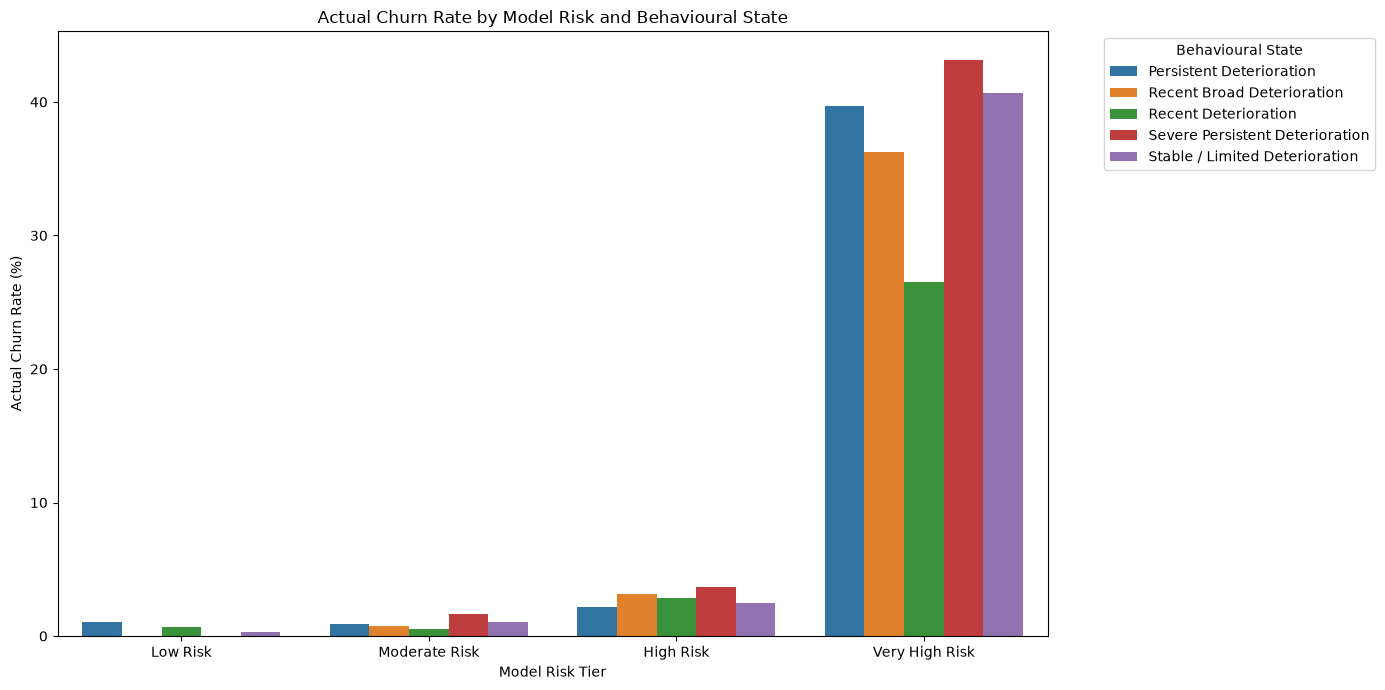

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.barplot(
    data=risk_state_summary,
    x="risk_tier",
    y="actual_churn_rate",
    hue="behavioral_state"
)

plt.title("Actual Churn Rate by Model Risk and Behavioural State")
plt.xlabel("Model Risk Tier")
plt.ylabel("Actual Churn Rate (%)")
plt.legend(
    title="Behavioural State",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [42]:
# Summarise each risk-behaviour segment using both its size
# and its contribution to observed churn.

risk_behavior_business = (
    risk_behavior_df
    .groupby(
        ["risk_tier", "behavioral_state"],
        observed=True
    )
    .agg(
        customers=("id", "size"),
        actual_churners=("churn_probability", "sum"),
        actual_churn_rate=("churn_probability", "mean"),
        average_model_risk=("predicted_churn_risk", "mean")
    )
    .reset_index()
)

risk_behavior_business["actual_churn_rate"] *= 100

risk_behavior_business["churner_share_pct"] = (
    risk_behavior_business["actual_churners"]
    / risk_behavior_business["actual_churners"].sum()
    * 100
)

display(
    risk_behavior_business.sort_values(
        "actual_churners",
        ascending=False
    )
)

,risk_tier,behavioral_state,customers,actual_churners,actual_churn_rate,average_model_risk,churner_share_pct
19,Very High Risk,Stable / Limited Deterioration,946,385,40.697674,0.498932,26.998597
15,Very High Risk,Persistent Deterioration,703,279,39.687055,0.471716,19.565217
18,Very High Risk,Severe Persistent Deterioration,626,270,43.130990,0.515218,18.934081
17,Very High Risk,Recent Deterioration,811,215,26.510481,0.350440,15.077139
16,Very High Risk,Recent Broad Deterioration,378,137,36.243386,0.439171,9.607293
12,High Risk,Recent Deterioration,1165,33,2.832618,0.081408,2.314165
14,High Risk,Stable / Limited Deterioration,1144,28,2.447552,0.079193,1.963534
10,High Risk,Persistent Deterioration,653,14,2.143951,0.081445,0.981767
9,Moderate Risk,Stable / Limited Deterioration,1378,14,1.015965,0.031372,0.981767
13,High Risk,Severe Persistent Deterioration,243,9,3.703704,0.086091,0.631136


In [43]:
# Focus the analysis on the customers classified as Very High Risk.
# This allows us to investigate behavioural differences inside the
# population that contributes the majority of observed churners.

very_high_risk = risk_behavior_df[
    risk_behavior_df["risk_tier"] == "Very High Risk"
].copy()

print(f"Very High Risk customers: {len(very_high_risk)}")
print(
    f"Actual churners: "
    f"{very_high_risk['churn_probability'].sum()}"
)

display(
    very_high_risk.groupby("behavioral_state")
    .agg(
        customers=("id", "size"),
        churners=("churn_probability", "sum"),
        churn_rate=("churn_probability", "mean"),
        average_risk=("predicted_churn_risk", "mean")
    )
    .sort_values("churn_rate", ascending=False)
)

Very High Risk customers: 3464
Actual churners: 1286


,customers,churners,churn_rate,average_risk
behavioral_state,,,,
Severe Persistent Deterioration,626,270,0.431310,0.515218
Stable / Limited Deterioration,946,385,0.406977,0.498932
Persistent Deterioration,703,279,0.396871,0.471716
Recent Broad Deterioration,378,137,0.362434,0.439171
Recent Deterioration,811,215,0.265105,0.350440


In [44]:
# Examine August ARPU among Very High Risk customers.
# ARPU is used as an observed revenue proxy, not as customer lifetime value.

very_high_risk_value = df.loc[
    very_high_risk.index,
    [
        "id",
        "arpu_8",
        "churn_probability",
        "behavioral_state"
    ]
].copy()

print("August ARPU distribution among Very High Risk customers:")

display(
    very_high_risk_value["arpu_8"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

August ARPU distribution among Very High Risk customers:


count     3464.000000
mean       191.528268
std        466.001332
min        -43.170000
25%          1.000000
50%         72.902500
75%        226.362000
90%        480.066600
95%        766.276450
max      19295.904000
Name: arpu_8, dtype: float64

In [45]:
# -------------------------------------------------------------------------
# BUSINESS ANALYSIS DATASET
# -------------------------------------------------------------------------
# Purpose:
# Combine the three dimensions currently available to the project:
#
# 1. Model risk       -> likelihood of churn according to the predictive model
# 2. Behavioural state -> observed pattern of customer deterioration
# 3. Customer value   -> current revenue contribution represented by August ARPU
#
# This dataset is constructed only from the validation population so that
# business analysis remains separated from the data used to fit the model.
# -------------------------------------------------------------------------

risk_value_df = df.loc[
    X_valid_enhanced.index,
    [
        "id",
        "arpu_8",
        "churn_probability",
        "behavioral_state"
    ]
].copy()

# The Random Forest's positive-class probability is used as the model's
# churn-risk score. It is treated as a ranking signal here rather than
# assuming that the numerical value is perfectly calibrated as a probability.
risk_value_df["predicted_churn_risk"] = y_valid_proba_behavioral

print("Validation population prepared for value-aware analysis.")
print(f"Customers analysed: {len(risk_value_df):,}")

display(risk_value_df.head())

Validation population prepared for value-aware analysis.
Customers analysed: 14,000


,id,arpu_8,churn_probability,behavioral_state,predicted_churn_risk
25294,25294,35.192,0,Stable / Limited Deterioration,0.086667
24327,24327,0.970,0,Persistent Deterioration,0.806667
58676,58676,109.958,0,Stable / Limited Deterioration,0.060000
32271,32271,435.348,0,Stable / Limited Deterioration,0.023333
25682,25682,411.319,0,Persistent Deterioration,0.223333


In [46]:
# -------------------------------------------------------------------------
# PREPARE VALUE-AWARE CUSTOMER ANALYSIS DATASET
# -------------------------------------------------------------------------
# The previous risk-behaviour analysis already assigned each validation
# customer to a model-risk tier and behavioural state.
#
# The current analysis adds August ARPU as an observed customer-value proxy.
# We therefore reuse the existing risk-tier assignment instead of rebuilding
# it, ensuring that the risk segmentation remains consistent across analyses.
#
# ARPU is treated only as an observed current-value indicator. It is not
# interpreted as Customer Lifetime Value (CLV), since the dataset does not
# provide the information required to estimate future customer value.
# -------------------------------------------------------------------------

risk_value_df = risk_behavior_df[
    [
        "id",
        "risk_tier",
        "behavioral_state",
        "churn_probability",
        "predicted_churn_risk"
    ]
].copy()

# Attach August ARPU from the original prepared dataset.
# The customer ID provides the stable key for this analytical merge.
risk_value_df = risk_value_df.merge(
    df[
        [
            "id",
            "arpu_8"
        ]
    ],
    on="id",
    how="left"
)

print("Value-aware analysis dataset prepared.")
print(f"Customers analysed : {len(risk_value_df):,}")
print(f"Missing August ARPU: {risk_value_df['arpu_8'].isna().sum()}")

display(risk_value_df.head())

Value-aware analysis dataset prepared.
Customers analysed : 14,000
Missing August ARPU: 0


,id,risk_tier,behavioral_state,churn_probability,predicted_churn_risk,arpu_8
0,25294,High Risk,Stable / Limited Deterioration,0,0.086667,35.192
1,24327,Very High Risk,Persistent Deterioration,0,0.806667,0.970
2,58676,High Risk,Stable / Limited Deterioration,0,0.060000,109.958
3,32271,Moderate Risk,Stable / Limited Deterioration,0,0.023333,435.348
4,25682,Very High Risk,Persistent Deterioration,0,0.223333,411.319


In [47]:
# -------------------------------------------------------------------------
# RELATIVE CUSTOMER-VALUE SEGMENTATION
# -------------------------------------------------------------------------
# August ARPU is divided into four relative segments using quartiles.
#
# Quartile segmentation is used because the observed ARPU distribution is
# highly right-skewed and contains extreme values. Relative segments allow
# comparison between lower- and higher-value customers without imposing
# arbitrary absolute revenue thresholds.
#
# These categories describe relative value within this validation population;
# they should not be interpreted as official telecom customer-value classes.
# -------------------------------------------------------------------------

risk_value_df["value_tier"] = pd.qcut(
    risk_value_df["arpu_8"],
    q=4,
    labels=[
        "Lower Value",
        "Moderate Value",
        "Higher Value",
        "Highest Value"
    ],
    duplicates="drop"
)

print("Customer-value segment distribution:")

display(
    risk_value_df["value_tier"]
    .value_counts()
    .sort_index()
)

Customer-value segment distribution:


value_tier
Lower Value       3500
Moderate Value    3500
Higher Value      3500
Highest Value     3500
Name: count, dtype: int64

In [48]:
# -------------------------------------------------------------------------
# RISK × BEHAVIOUR × VALUE ANALYSIS
# -------------------------------------------------------------------------
# This analysis examines whether model risk and behavioural state interact
# with observed customer value.
#
# The purpose is business prioritisation analysis rather than predictive
# model development. We are testing whether customers with similar churn
# risk exhibit materially different business importance depending on their
# behavioural condition and current revenue contribution.
#
# The aggregation reports:
#
# - customer population size,
# - actual churners,
# - observed churn rate,
# - average model risk,
# - average August ARPU,
# - aggregate August ARPU across the segment.
#
# Aggregate ARPU represents the revenue scale of the segment. It must not
# be interpreted as revenue that can be saved, because the current dataset
# contains no intervention outcomes demonstrating that churn could have
# been prevented.
# -------------------------------------------------------------------------

risk_behavior_value_summary = (
    risk_value_df
    .groupby(
        [
            "risk_tier",
            "behavioral_state",
            "value_tier"
        ],
        observed=True
    )
    .agg(
        customers=("id", "size"),

        actual_churners=(
            "churn_probability",
            "sum"
        ),

        actual_churn_rate=(
            "churn_probability",
            "mean"
        ),

        average_model_risk=(
            "predicted_churn_risk",
            "mean"
        ),

        average_arpu=(
            "arpu_8",
            "mean"
        ),

        total_arpu=(
            "arpu_8",
            "sum"
        )
    )
    .reset_index()
)

# Express the target mean as a percentage for easier business interpretation.
risk_behavior_value_summary["actual_churn_rate"] *= 100

display(
    risk_behavior_value_summary
    .sort_values(
        [
            "risk_tier",
            "actual_churners"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,risk_tier,behavioral_state,value_tier,customers,actual_churners,actual_churn_rate,average_model_risk,average_arpu,total_arpu
19,Low Risk,Stable / Limited Deterioration,Highest Value,574,4,0.696864,0.007921,604.472037,346966.949
2,Low Risk,Persistent Deterioration,Higher Value,153,3,1.960784,0.008322,271.021105,41466.229
8,Low Risk,Recent Deterioration,Lower Value,161,3,1.863354,0.008758,61.382354,9882.559
10,Low Risk,Recent Deterioration,Higher Value,397,3,0.755668,0.007657,275.563463,109398.695
9,Low Risk,Recent Deterioration,Moderate Value,408,2,0.490196,0.008056,141.399093,57690.830
...,...,...,...,...,...,...,...,...,...
74,Very High Risk,Severe Persistent Deterioration,Higher Value,52,18,34.615385,0.327756,269.737731,14026.362
66,Very High Risk,Recent Broad Deterioration,Higher Value,65,17,26.153846,0.369590,258.860569,16825.937
63,Very High Risk,Persistent Deterioration,Highest Value,70,16,22.857143,0.256571,723.062743,50614.392
67,Very High Risk,Recent Broad Deterioration,Highest Value,36,9,25.000000,0.288611,689.204833,24811.374


In [49]:
# -------------------------------------------------------------------------
# RISK × VALUE PRIORITISATION MATRIX
# -------------------------------------------------------------------------
# The purpose of this analysis is to determine how customer value changes
# the business significance of predicted churn risk.
#
# Risk is represented by the existing model-risk tier.
# Value is represented by the relative August-ARPU tier.
#
# No arbitrary numerical weighting is introduced at this stage.
# This avoids imposing subjective assumptions about how much risk should
# outweigh customer value, or vice versa.
# -------------------------------------------------------------------------

risk_value_matrix = (
    risk_value_df
    .groupby(
        [
            "risk_tier",
            "value_tier"
        ],
        observed=True
    )
    .agg(
        customers=("id", "size"),

        actual_churners=(
            "churn_probability",
            "sum"
        ),

        actual_churn_rate=(
            "churn_probability",
            "mean"
        ),

        average_model_risk=(
            "predicted_churn_risk",
            "mean"
        ),

        average_arpu=(
            "arpu_8",
            "mean"
        ),

        total_arpu=(
            "arpu_8",
            "sum"
        )
    )
    .reset_index()
)

# Convert the observed target mean into a percentage for interpretation.
risk_value_matrix["actual_churn_rate"] *= 100

display(
    risk_value_matrix
    .sort_values(
        [
            "risk_tier",
            "value_tier"
        ]
    )
)

,risk_tier,value_tier,customers,actual_churners,actual_churn_rate,average_model_risk,average_arpu,total_arpu
0,Low Risk,Lower Value,405,4,0.987654,0.009342,61.814202,25034.752
1,Low Risk,Moderate Value,1129,4,0.354296,0.008208,140.780182,158940.826
2,Low Risk,Higher Value,1176,7,0.595238,0.007775,275.256254,323701.355
3,Low Risk,Highest Value,1009,5,0.495540,0.008196,588.076926,593369.618
4,Moderate Risk,Lower Value,494,4,0.809717,0.032773,55.304575,27320.460
5,Moderate Risk,Moderate Value,908,12,1.321586,0.031178,140.629026,127691.156
6,Moderate Risk,Higher Value,974,5,0.513347,0.031684,272.649565,265560.676
7,Moderate Risk,Highest Value,982,7,0.712831,0.031477,654.099706,642325.911
8,High Risk,Lower Value,785,20,2.547771,0.084684,44.483005,34919.159
9,High Risk,Moderate Value,840,37,4.404762,0.080817,138.848511,116632.749


In [50]:
# -------------------------------------------------------------------------
# VERY HIGH RISK VALUE PRIORITISATION
# -------------------------------------------------------------------------
# This subset represents customers already identified by the predictive
# model as belonging to the highest-risk quartile.
#
# The analysis now asks whether customer value meaningfully differentiates
# the business importance of customers within this already high-risk group.
# -------------------------------------------------------------------------

very_high_risk_value = risk_value_df[
    risk_value_df["risk_tier"] == "Very High Risk"
].copy()

print(
    f"Very High Risk customers: "
    f"{len(very_high_risk_value):,}"
)

print(
    f"Actual churners: "
    f"{very_high_risk_value['churn_probability'].sum():,.0f}"
)

display(
    very_high_risk_value
    .groupby(
        "value_tier",
        observed=True
    )
    .agg(
        customers=("id", "size"),

        actual_churners=(
            "churn_probability",
            "sum"
        ),

        actual_churn_rate=(
            "churn_probability",
            "mean"
        ),

        average_model_risk=(
            "predicted_churn_risk",
            "mean"
        ),

        average_arpu=(
            "arpu_8",
            "mean"
        ),

        total_arpu=(
            "arpu_8",
            "sum"
        )
    )
    .assign(
        actual_churn_rate=lambda x:
            x["actual_churn_rate"] * 100
    )
    .sort_values(
        "average_arpu",
        ascending=False
    )
)

Very High Risk customers: 3,464
Actual churners: 1,286


,customers,actual_churners,actual_churn_rate,average_model_risk,average_arpu,total_arpu
value_tier,,,,,,
Highest Value,506,96,18.972332,0.256449,806.472652,408075.162
Higher Value,519,126,24.277457,0.322768,267.641514,138905.946
Moderate Value,623,160,25.682183,0.322386,135.178342,84216.107
Lower Value,1816,904,49.779736,0.593733,17.762502,32256.704


In [51]:
# -------------------------------------------------------------------------
# CUSTOMER BEHAVIOUR → CANDIDATE ACTION SIGNALS
# -------------------------------------------------------------------------
# The objective is to translate observable behavioural deterioration into
# operational categories that could guide retention review.
#
# These are candidate action signals, not causal diagnoses. The current
# dataset does not contain intervention history or treatment outcomes.
# -------------------------------------------------------------------------

action_df = df.loc[
    very_high_risk_value.index
].copy()

action_df["action_signal"] = "General Retention Review"

# Strong recharge deterioration
recharge_decline = (
    (action_df["recharge_amount_jul_aug_change"] < 0) &
    (action_df["recharge_count_jul_aug_change"] < 0)
)

# Strong usage deterioration
usage_decline = (
    (action_df["outgoing_mou_jul_aug_change"] < 0) &
    (action_df["incoming_mou_jul_aug_change"] < 0)
)

# Broad recent deterioration
broad_recent_decline = (
    action_df["recent_deterioration_count"] >= 4
)

# Persistent deterioration
persistent_decline = (
    action_df["persistent_deterioration_count"] >= 2
)

action_df.loc[
    recharge_decline,
    "action_signal"
] = "Recharge / Affordability Review"

action_df.loc[
    usage_decline,
    "action_signal"
] = "Usage / Engagement Review"

action_df.loc[
    persistent_decline,
    "action_signal"
] = "Persistent Deterioration Review"

action_df.loc[
    broad_recent_decline,
    "action_signal"
] = "Broad Recent Deterioration Review"

print("Candidate action-signal distribution:")
display(
    action_df["action_signal"]
    .value_counts()
)

Candidate action-signal distribution:


action_signal
General Retention Review             1633
Broad Recent Deterioration Review    1155
Persistent Deterioration Review       310
Recharge / Affordability Review       199
Usage / Engagement Review             167
Name: count, dtype: int64

In [52]:
# -------------------------------------------------------------------------
# FINAL RETENTION PRIORITY
# -------------------------------------------------------------------------
# Retention priority is derived from observable business dimensions rather
# than an arbitrary weighted score.
#
# Priority 1:
# High churn risk + higher observed customer value.
#
# Priority 2:
# High churn risk + behavioural deterioration requiring attention.
#
# Priority 3:
# High churn risk requiring scalable/general retention treatment.
#
# These priorities represent decision-support categories, not proven
# intervention effectiveness.
# -------------------------------------------------------------------------

priority_df = risk_value_df.copy()

priority_df["retention_priority"] = "Priority 3"

# Highest business priority:
# Very high churn risk combined with relatively high observed customer value.
priority_df.loc[
    (
        (priority_df["risk_tier"] == "Very High Risk") &
        (
            priority_df["value_tier"].isin(
                ["Higher Value", "Highest Value"]
            )
        )
    ),
    "retention_priority"
] = "Priority 1"


# Behaviourally urgent customers:
# Very high risk with strong persistent or broad recent deterioration.
priority_df.loc[
    (
        (priority_df["risk_tier"] == "Very High Risk") &
        (
            priority_df["behavioral_state"].isin(
                [
                    "Severe Persistent Deterioration",
                    "Persistent Deterioration",
                    "Recent Broad Deterioration"
                ]
            )
        )
    ),
    "retention_priority"
] = "Priority 2"


# Value-aware Priority 1 remains dominant when both conditions apply.
priority_df.loc[
    (
        (priority_df["risk_tier"] == "Very High Risk") &
        (
            priority_df["value_tier"].isin(
                ["Higher Value", "Highest Value"]
            )
        )
    ),
    "retention_priority"
] = "Priority 1"


priority_summary = (
    priority_df
    .groupby(
        "retention_priority"
    )
    .agg(
        customers=("id", "size"),
        actual_churners=("churn_probability", "sum"),
        actual_churn_rate=("churn_probability", "mean"),
        average_model_risk=("predicted_churn_risk", "mean"),
        average_arpu=("arpu_8", "mean"),
        total_arpu=("arpu_8", "sum")
    )
    .reset_index()
)

priority_summary["actual_churn_rate"] *= 100

display(
    priority_summary
    .sort_values("retention_priority")
)

,retention_priority,customers,actual_churners,actual_churn_rate,average_model_risk,average_arpu,total_arpu
0,Priority 1,1025,222,21.658537,0.290029,533.640105,546981.108
1,Priority 2,1367,596,43.599122,0.523402,39.713350,54288.150
2,Priority 3,11608,608,5.237767,0.084590,289.571401,3361344.824


In [53]:
# -------------------------------------------------------------------------
# PRIORITY × BEHAVIOURAL ACTION ROUTING
# -------------------------------------------------------------------------
# Combine the final retention priority with the observed behavioural
# pattern to create the operational retention-review view.
# -------------------------------------------------------------------------

final_retention_view = priority_df[
    [
        "id",
        "risk_tier",
        "behavioral_state",
        "value_tier",
        "predicted_churn_risk",
        "arpu_8",
        "retention_priority"
    ]
].copy()

final_retention_view["action_signal"] = "General Retention Review"

final_retention_view.loc[
    final_retention_view["behavioral_state"]
    == "Recent Broad Deterioration",
    "action_signal"
] = "Broad Recent Deterioration Review"

final_retention_view.loc[
    final_retention_view["behavioral_state"].isin(
        [
            "Persistent Deterioration",
            "Severe Persistent Deterioration"
        ]
    ),
    "action_signal"
] = "Persistent Deterioration Review"

# Summarise the final operational segments.
final_action_summary = (
    final_retention_view
    .groupby(
        [
            "retention_priority",
            "action_signal"
        ]
    )
    .size()
    .reset_index(name="customers")
    .sort_values(
        ["retention_priority", "customers"],
        ascending=[True, False]
    )
)

display(final_action_summary)

,retention_priority,action_signal,customers
1,Priority 1,General Retention Review,685
2,Priority 1,Persistent Deterioration Review,239
0,Priority 1,Broad Recent Deterioration Review,101
4,Priority 2,Persistent Deterioration Review,1090
3,Priority 2,Broad Recent Deterioration Review,277
6,Priority 3,General Retention Review,9048
7,Priority 3,Persistent Deterioration Review,2095
5,Priority 3,Broad Recent Deterioration Review,465


In [54]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Evaluate multiple probability thresholds to determine how the operating
# point affects false negatives and false positives. The Random Forest model
# remains unchanged; only the classification decision boundary is varied.
threshold_results = []

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]:

    # Convert predicted churn probabilities into binary churn decisions.
    # Customers meeting or exceeding the threshold are flagged as churners.
    predictions = (
        y_valid_proba_behavioral >= threshold
    ).astype(int)

    # Extract confusion-matrix outcomes:
    # TN = correctly identified non-churners
    # FP = non-churners incorrectly flagged
    # FN = actual churners missed by the model
    # TP = correctly identified churners
    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        predictions,
        labels=[0, 1]
    ).ravel()

    # Record predictive metrics and error counts for each operating point.
    # Recall is particularly important because false negatives represent
    # churners that the retention system fails to identify.
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_valid, predictions),
        "recall": recall_score(y_valid, predictions),
        "f1": f1_score(y_valid, predictions),
        "false_negatives": fn,
        "false_positives": fp
    })

# Convert the experiment results into a structured comparison table.
threshold_df = pd.DataFrame(threshold_results)

# Round only the presentation values so the underlying calculations remain
# unchanged and the results are easier to compare across thresholds.
threshold_display = threshold_df.copy()

threshold_display["precision"] = threshold_display["precision"].round(3)
threshold_display["recall"] = threshold_display["recall"].round(3)
threshold_display["f1"] = threshold_display["f1"].round(3)

display(threshold_display)

,threshold,precision,recall,f1,false_negatives,false_positives
0,0.50,0.720,0.650,0.683,499,360
1,0.45,0.697,0.680,0.688,456,422
2,0.40,0.671,0.706,0.688,419,493
3,0.35,0.632,0.736,0.680,376,612
4,0.30,0.587,0.771,0.667,327,772
5,0.25,0.542,0.809,0.649,273,974
6,0.20,0.472,0.846,0.606,219,1352
7,0.15,0.393,0.891,0.546,156,1959
8,0.10,0.303,0.930,0.457,100,3049


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# -------------------------------------------------------------------------
# RANDOM FOREST HYPERPARAMETER SEARCH
# -------------------------------------------------------------------------
# The objective is to determine whether the Random Forest architecture can
# be improved before introducing a different model family.
#
# The search focuses on parameters that control tree complexity and class
# treatment. The validation set remains untouched until each configuration
# is evaluated.
# -------------------------------------------------------------------------

rf_param_grid = {
    "max_depth": [None, 12, 18],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", 0.5],
    "class_weight": ["balanced"]
}

parameter_combinations = list(
    ParameterGrid(rf_param_grid)
)

print(
    f"Random Forest configurations to evaluate: "
    f"{len(parameter_combinations)}"
)

Random Forest configurations to evaluate: 24


In [56]:
# -------------------------------------------------------------------------
# RELATIVE CUSTOMER-VALUE SEGMENTATION
# -------------------------------------------------------------------------
# August ARPU is divided into four relative segments using quartiles.
#
# Quartile segmentation is used because the observed ARPU distribution is
# highly right-skewed and contains extreme values. Relative segments allow
# comparison between lower- and higher-value customers without imposing
# arbitrary absolute revenue thresholds.
#
# These categories describe relative value within this validation population;
# they should not be interpreted as official telecom customer-value classes.
# -------------------------------------------------------------------------

risk_value_df["value_tier"] = pd.qcut(
    risk_value_df["arpu_8"],
    q=4,
    labels=[
        "Lower Value",
        "Moderate Value",
        "Higher Value",
        "Highest Value"
    ],
    duplicates="drop"
)

print("Customer-value segment distribution:")

display(
    risk_value_df["value_tier"]
    .value_counts()
    .sort_index()
)

Customer-value segment distribution:


value_tier
Lower Value       3500
Moderate Value    3500
Higher Value      3500
Highest Value     3500
Name: count, dtype: int64

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# -------------------------------------------------------------------------
# CONTROLLED RANDOM FOREST HYPERPARAMETER SEARCH
# -------------------------------------------------------------------------
# The objective is to determine whether changes to Random Forest complexity
# and class weighting can improve the false-negative / false-positive
# trade-off without changing the model family.
#
# A compact search is used to keep experimentation computationally practical
# while covering the parameters most relevant to model generalization.
# -------------------------------------------------------------------------

rf_param_grid = {
    "max_depth": [12, 18, None],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", 0.5],
    "class_weight": ["balanced"]
}

parameter_combinations = list(
    ParameterGrid(rf_param_grid)
)

print(
    f"Random Forest configurations to evaluate: "
    f"{len(parameter_combinations)}"
)

rf_tuning_results = []

for config_number, params in enumerate(
    parameter_combinations,
    start=1
):

    print(
        f"Training configuration "
        f"{config_number}/{len(parameter_combinations)}..."
    )

    # Use fewer trees during the search stage to identify promising
    # configurations efficiently. The final selected configuration can
    # later be retrained with a larger forest.
    rf_model = RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1,
        **params
    )

    # Fit exclusively on the training partition. The validation partition
    # remains unseen during model fitting.
    rf_model.fit(
        X_train,
        y_train
    )

    # Probability estimates allow us to evaluate the model independently
    # of the eventual classification threshold.
    valid_proba = rf_model.predict_proba(
        X_valid
    )[:, 1]

    # Evaluate the current configuration at the standard threshold so that
    # its FN/FP behaviour can be compared consistently with the existing
    # Random Forest baseline.
    valid_pred = (
        valid_proba >= 0.50
    ).astype(int)

    # Extract confusion-matrix outcomes for explicit false-negative and
    # false-positive analysis.
    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        valid_pred,
        labels=[0, 1]
    ).ravel()

    rf_tuning_results.append({
        "configuration": config_number,
        **params,
        "roc_auc": roc_auc_score(
            y_valid,
            valid_proba
        ),
        "pr_auc": average_precision_score(
            y_valid,
            valid_proba
        ),
        "precision": precision_score(
            y_valid,
            valid_pred
        ),
        "recall": recall_score(
            y_valid,
            valid_pred
        ),
        "f1": f1_score(
            y_valid,
            valid_pred
        ),
        "false_negatives": fn,
        "false_positives": fp
    })

# Consolidate all configurations into a single experiment table for
# comparison and subsequent selection of promising candidates.
rf_tuning_df = pd.DataFrame(
    rf_tuning_results
)

print("\nRandom Forest tuning completed.")
print(f"Configurations evaluated: {len(rf_tuning_df)}")

Random Forest configurations to evaluate: 12
Training configuration 1/12...
Training configuration 2/12...
Training configuration 3/12...
Training configuration 4/12...
Training configuration 5/12...
Training configuration 6/12...
Training configuration 7/12...
Training configuration 8/12...
Training configuration 9/12...
Training configuration 10/12...
Training configuration 11/12...
Training configuration 12/12...

Random Forest tuning completed.
Configurations evaluated: 12


In [ ]:
# Rank configurations by PR-AUC to identify Random Forest variants with
# stronger discrimination of the minority churn class.

rf_tuning_summary = (
    rf_tuning_df
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_tuning_summary[
        [
            "configuration",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "pr_auc",
            "roc_auc",
            "precision",
            "recall",
            "f1",
            "false_negatives",
            "false_positives"
        ]
    ].round(4)
)

,configuration,max_depth,min_samples_leaf,max_features,pr_auc,roc_auc,precision,recall,f1,false_negatives,false_positives
0,3,12.0,1,0.5,0.7345,0.9370,0.6176,0.7658,0.6838,334,676
1,4,12.0,5,0.5,0.7331,0.9370,0.6073,0.7742,0.6806,322,714
2,8,18.0,5,0.5,0.7304,0.9366,0.6371,0.7511,0.6894,355,610
3,2,12.0,5,sqrt,0.7291,0.9365,0.6060,0.7496,0.6702,357,695
4,12,NaN,5,0.5,0.7288,0.9361,0.6344,0.7447,0.6852,364,612
5,10,NaN,5,sqrt,0.7281,0.9361,0.6441,0.7272,0.6831,389,573
6,6,18.0,5,sqrt,0.7280,0.9356,0.6347,0.7237,0.6763,394,594
7,7,18.0,1,0.5,0.7247,0.9342,0.6577,0.7195,0.6872,400,534
8,1,12.0,1,sqrt,0.7211,0.9354,0.6220,0.7384,0.6752,373,640
9,5,18.0,1,sqrt,0.7205,0.9356,0.6883,0.6830,0.6857,452,441


In [ ]:
# -------------------------------------------------------------------------
# RETRAIN TOP RANDOM FOREST CONFIGURATIONS
# -------------------------------------------------------------------------
# The hyperparameter search identified several promising configurations.
# These models are now retrained with a larger forest so that their
# probability outputs can be evaluated more reliably during threshold
# analysis.
#
# The same training and validation partitions are retained to ensure a
# fair comparison with the original Random Forest experiment.
# -------------------------------------------------------------------------

top_rf_configs = {
    "RF_Config_3": {
        "max_depth": 12,
        "min_samples_leaf": 1,
        "max_features": 0.5,
        "class_weight": "balanced"
    },
    "RF_Config_4": {
        "max_depth": 12,
        "min_samples_leaf": 5,
        "max_features": 0.5,
        "class_weight": "balanced"
    },
    "RF_Config_8": {
        "max_depth": 18,
        "min_samples_leaf": 1,
        "max_features": 0.5,
        "class_weight": "balanced"
    }
}

top_rf_models = {}
top_rf_probabilities = {}

for model_name, params in top_rf_configs.items():

    print(f"Training {model_name}...")

    # Use a larger forest than the initial hyperparameter search so that
    # the selected configurations are evaluated using a more stable
    # ensemble before threshold selection.
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        **params
    )

    # Fit the selected configuration exclusively on the training data.
    model.fit(
        X_train,
        y_train
    )

    # Store the trained model for possible reuse during later analysis
    # and deployment-oriented stages.
    top_rf_models[model_name] = model

    # Retain probability estimates rather than fixed class predictions.
    # These probabilities allow the operating threshold to be changed
    # without retraining the model.
    top_rf_probabilities[model_name] = (
        model.predict_proba(X_valid)[:, 1]
    )

    print(f"{model_name} training completed.")

print("\nSelected Random Forest models are ready for threshold analysis.")

Training RF_Config_3...
RF_Config_3 training completed.
Training RF_Config_4...
RF_Config_4 training completed.
Training RF_Config_8...
RF_Config_8 training completed.

Selected Random Forest models are ready for threshold analysis.


In [ ]:
# -------------------------------------------------------------------------
# THRESHOLD ANALYSIS FOR SELECTED RANDOM FOREST MODELS
# -------------------------------------------------------------------------
# Each selected Random Forest is evaluated across the same probability
# thresholds used previously.
#
# The purpose is to determine whether a tuned Random Forest can achieve
# fewer false negatives without producing an excessive number of false
# positives.
# -------------------------------------------------------------------------

rf_threshold_results = []

thresholds = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30,
    0.25,
    0.20
]

for model_name, probabilities in top_rf_probabilities.items():

    for threshold in thresholds:

        # Convert probability estimates into binary churn decisions using
        # the current operating threshold.
        predictions = (
            probabilities >= threshold
        ).astype(int)

        # Extract confusion-matrix outcomes to explicitly quantify missed
        # churners and incorrectly flagged non-churners.
        tn, fp, fn, tp = confusion_matrix(
            y_valid,
            predictions,
            labels=[0, 1]
        ).ravel()

        rf_threshold_results.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(
                y_valid,
                predictions
            ),
            "recall": recall_score(
                y_valid,
                predictions
            ),
            "f1": f1_score(
                y_valid,
                predictions
            ),
            "false_negatives": fn,
            "false_positives": fp
        })

rf_threshold_df = pd.DataFrame(
    rf_threshold_results
)

# Sort the results by model and threshold so that the movement from a
# conservative to an aggressive retention threshold is easy to inspect.
rf_threshold_df = rf_threshold_df.sort_values(
    ["model", "threshold"],
    ascending=[True, False]
).reset_index(drop=True)

display(
    rf_threshold_df.round(4)
)

,model,threshold,precision,recall,f1,false_negatives,false_positives
0,RF_Config_3,0.50,0.6152,0.7658,0.6823,334,683
1,RF_Config_3,0.45,0.5899,0.7868,0.6743,304,780
2,RF_Config_3,0.40,0.5585,0.8065,0.6600,276,909
3,RF_Config_3,0.35,0.5267,0.8289,0.6441,244,1062
4,RF_Config_3,0.30,0.4868,0.8548,0.6204,207,1285
5,RF_Config_3,0.25,0.4405,0.8780,0.5867,174,1590
6,RF_Config_3,0.20,0.3885,0.8969,0.5422,147,2013
7,RF_Config_4,0.50,0.6059,0.7763,0.6806,319,720
8,RF_Config_4,0.45,0.5744,0.7987,0.6682,287,844
9,RF_Config_4,0.40,0.5405,0.8198,0.6514,257,994


In [ ]:
# -------------------------------------------------------------------------
# FINAL CHURN MODEL CONFIGURATION
# -------------------------------------------------------------------------
# This model configuration was selected through the RF tuning experiments.
# A 0.50 decision threshold is retained as the practical operating point
# based on the previously evaluated precision-recall trade-off.
# -------------------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

FINAL_THRESHOLD = 0.50

final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=1,
    max_features=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_train,
    y_train
)

print("Final Random Forest model trained successfully.")
print(f"Decision threshold: {FINAL_THRESHOLD}")

Final Random Forest model trained successfully.
Decision threshold: 0.5


In [ ]:
# -------------------------------------------------------------------------
# FINAL VALIDATION EVALUATION
# -------------------------------------------------------------------------
# The validation set is used only to report the performance of the selected
# model at the fixed operating threshold.
# -------------------------------------------------------------------------

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

final_valid_proba = final_rf.predict_proba(
    X_valid
)[:, 1]

final_valid_pred = (
    final_valid_proba >= FINAL_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_valid,
    final_valid_pred
).ravel()

print("FINAL CHURN MODEL")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_valid, final_valid_proba):.4f}")
print(f"PR-AUC    : {average_precision_score(y_valid, final_valid_proba):.4f}")
print(f"Precision : {precision_score(y_valid, final_valid_pred):.4f}")
print(f"Recall    : {recall_score(y_valid, final_valid_pred):.4f}")
print(f"F1        : {f1_score(y_valid, final_valid_pred):.4f}")
print(f"TP        : {tp}")
print(f"FP        : {fp}")
print(f"FN        : {fn}")
print(f"TN        : {tn}")

FINAL CHURN MODEL
ROC-AUC   : 0.9349
PR-AUC    : 0.7272
Precision : 0.6596
Recall    : 0.7216
F1        : 0.6892
TP        : 1029
FP        : 531
FN        : 397
TN        : 12043


In [ ]:
# -------------------------------------------------------------------------
# COST-SENSITIVE ERROR ANALYSIS
# -------------------------------------------------------------------------
# Evaluate the business impact of false positives (FP) and false negatives
# (FN) under different relative cost assumptions.
#
# This experiment does not retrain the model or change its predictions.
# It establishes how sensitive the current churn model is to asymmetric
# business costs before introducing cost-sensitive learning.
# -------------------------------------------------------------------------

cost_scenarios = [
    {"FP_cost": 1, "FN_cost": 1},
    {"FP_cost": 1, "FN_cost": 2},
    {"FP_cost": 1, "FN_cost": 3},
    {"FP_cost": 1, "FN_cost": 5},
    {"FP_cost": 1, "FN_cost": 10}
]

cost_results = []

for scenario in cost_scenarios:

    fp_cost = scenario["FP_cost"]
    fn_cost = scenario["FN_cost"]

    total_cost = (
        fp * fp_cost
        + fn * fn_cost
    )

    cost_results.append({
        "FP Cost": fp_cost,
        "FN Cost": fn_cost,
        "False Positives": fp,
        "False Negatives": fn,
        "Total Cost": total_cost
    })

cost_analysis = pd.DataFrame(cost_results)

display(cost_analysis)

,FP Cost,FN Cost,False Positives,False Negatives,Total Cost
0,1,1,531,397,928
1,1,2,531,397,1325
2,1,3,531,397,1722
3,1,5,531,397,2516
4,1,10,531,397,4501


In [ ]:
# -------------------------------------------------------------------------
# NORMALIZED COST COMPARISON
# -------------------------------------------------------------------------
# Normalize total cost relative to the 1:1 scenario so that the effect of
# increasing the penalty for missed churners can be interpreted easily.
# -------------------------------------------------------------------------

baseline_cost = cost_analysis.loc[
    cost_analysis["FP Cost"] == 1,
    "Total Cost"
].iloc[0]

cost_analysis["Relative Cost"] = (
    cost_analysis["Total Cost"] / baseline_cost
)

display(cost_analysis)

,FP Cost,FN Cost,False Positives,False Negatives,Total Cost,Relative Cost
0,1,1,531,397,928,1.000000
1,1,2,531,397,1325,1.427802
2,1,3,531,397,1722,1.855603
3,1,5,531,397,2516,2.711207
4,1,10,531,397,4501,4.850216


In [ ]:
cost_sensitive_configs = {
    "Balanced": "balanced",
    "FN_2x": {0: 1, 1: 2},
    "FN_3x": {0: 1, 1: 3},
    "FN_5x": {0: 1, 1: 5}
}

cost_model_results = []

for model_name, class_weight in cost_sensitive_configs.items():

    print(f"\nTraining: {model_name}")

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=1,
        max_features=0.5,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_valid)[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    tn, fp_value, fn_value, tp = confusion_matrix(
        y_valid,
        predictions
    ).ravel()

    cost_model_results.append({
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_valid, probabilities),
        "PR-AUC": average_precision_score(y_valid, probabilities),
        "Precision": precision_score(y_valid, predictions),
        "Recall": recall_score(y_valid, predictions),
        "F1": f1_score(y_valid, predictions),
        "FP": fp_value,
        "FN": fn_value,
        "TP": tp,
        "TN": tn
    })

cost_model_comparison = pd.DataFrame(cost_model_results)

3

display(
    cost_model_comparison.sort_values(
        "PR-AUC",
        ascending=False
    )
)


Training: Balanced

Training: FN_2x

Training: FN_3x

Training: FN_5x


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FP,FN,TP,TN
0,Balanced,0.934872,0.727241,0.659615,0.721599,0.689216,531,397,1029,12043
3,FN_5x,0.934139,0.726020,0.692857,0.680224,0.686483,430,456,970,12144
2,FN_3x,0.934191,0.725363,0.712644,0.652174,0.681069,375,496,930,12199
1,FN_2x,0.933584,0.723353,0.729773,0.632539,0.677686,334,524,902,12240


## 5. XGBoost Model

### Objective

Random Forest established a strong baseline for churn prediction. The next
experiment evaluates XGBoost to determine whether gradient-boosted decision
trees can capture additional nonlinear relationships and feature interactions
within the same prepared telecom dataset.

The experiment uses the same training and validation partitions and the same
feature representation used for the Random Forest benchmark.

No additional feature engineering, resampling, threshold optimization, or
hyperparameter tuning is introduced at this stage.

### Experimental Question

Can XGBoost improve churn-ranking and classification performance over the
Random Forest benchmark on the same prepared customer data?

### Evaluation Criteria

PR-AUC is treated as the primary ranking metric because churn is an imbalanced
target. Recall, precision, F1-score, and the resulting false-positive and
false-negative counts are used to evaluate the operational trade-off.

ROC-AUC is retained as a supporting metric.

In [58]:
# ---------------------------------------------------------
# XGBoost benchmark model
# ---------------------------------------------------------

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model initialized.")

XGBoost model initialized.


In [ ]:
# ---------------------------------------------------------
# XGBoost model training
# ---------------------------------------------------------

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

print("XGBoost model training completed.")

Training XGBoost...
XGBoost model training completed.


In [ ]:
# ---------------------------------------------------------
# Validation prediction
# ---------------------------------------------------------

xgb_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]

print("Validation predictions generated.")

Validation predictions generated.


In [ ]:
# ---------------------------------------------------------
# Validation prediction and classification performance
# ---------------------------------------------------------

xgb_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]

XGB_THRESHOLD = 0.50

xgb_valid_pred = (
    xgb_valid_proba >= XGB_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_valid,
    xgb_valid_pred
).ravel()

xgb_metrics = {
    "Model": "XGBoost",
    "ROC-AUC": roc_auc_score(y_valid, xgb_valid_proba),
    "PR-AUC": average_precision_score(y_valid, xgb_valid_proba),
    "Precision": precision_score(y_valid, xgb_valid_pred),
    "Recall": recall_score(y_valid, xgb_valid_pred),
    "F1": f1_score(y_valid, xgb_valid_pred),
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "TN": tn
}

xgb_results = pd.DataFrame([xgb_metrics])

display(xgb_results)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FP,FN,TP,TN
0,XGBoost,0.940596,0.738791,0.754127,0.608696,0.673652,283,558,868,12291


In [ ]:
# ---------------------------------------------------------
# Validation prediction and classification performance
# ---------------------------------------------------------

xgb_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]

XGB_THRESHOLD = 0.50

xgb_valid_pred = (
    xgb_valid_proba >= XGB_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_valid,
    xgb_valid_pred
).ravel()

xgb_metrics = {
    "Model": "XGBoost",
    "ROC-AUC": roc_auc_score(y_valid, xgb_valid_proba),
    "PR-AUC": average_precision_score(y_valid, xgb_valid_proba),
    "Precision": precision_score(y_valid, xgb_valid_pred),
    "Recall": recall_score(y_valid, xgb_valid_pred),
    "F1": f1_score(y_valid, xgb_valid_pred),
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "TN": tn
}

xgb_results = pd.DataFrame([xgb_metrics])

display(xgb_results)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FP,FN,TP,TN
0,XGBoost,0.940596,0.738791,0.754127,0.608696,0.673652,283,558,868,12291


In [ ]:
# ---------------------------------------------------------
# Model-family comparison
# ---------------------------------------------------------

rf_results = {
    "Model": "Random Forest",
    "ROC-AUC": 0.934872,
    "PR-AUC": 0.727241,
    "Precision": 0.659615,
    "Recall": 0.721599,
    "F1": 0.689216,
    "FP": 531,
    "FN": 397,
    "TP": 1029,
    "TN": 12043
}

model_comparison = pd.concat(
    [
        pd.DataFrame([rf_results]),
        xgb_results
    ],
    ignore_index=True
)

display(
    model_comparison.sort_values(
        by="PR-AUC",
        ascending=False
    )
)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FP,FN,TP,TN
1,XGBoost,0.940596,0.738791,0.754127,0.608696,0.673652,283,558,868,12291
0,Random Forest,0.934872,0.727241,0.659615,0.721599,0.689216,531,397,1029,12043


In [ ]:
# ---------------------------------------------------------
# XGBoost threshold analysis
# ---------------------------------------------------------

xgb_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

xgb_threshold_results = []

for threshold in xgb_thresholds:

    y_pred = (xgb_valid_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred
    ).ravel()

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)

display(xgb_threshold_df)

,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.20,0.635503,0.753156,0.689345,616,352,1074,11958
1,0.25,0.662461,0.736325,0.697443,535,376,1050,12039
2,0.30,0.685753,0.705470,0.695472,461,420,1006,12113
3,0.35,0.705584,0.682328,0.693761,406,453,973,12168
4,0.40,0.719110,0.657083,0.686698,366,489,937,12208
5,0.45,0.741408,0.635344,0.684290,316,520,906,12258
6,0.50,0.754127,0.608696,0.673652,283,558,868,12291


## 6. LightGBM Model

### Objective

XGBoost improved the ranking performance over Random Forest, while threshold
analysis showed that its operating point can be adjusted to balance precision
and recall.

The next experiment evaluates LightGBM as a second gradient-boosting approach
to determine whether its tree-learning strategy can provide additional
predictive performance on the same prepared telecom dataset.

The same training and validation partitions and feature representation are
retained to ensure a fair model comparison.

No additional feature engineering, resampling, threshold optimization, or
hyperparameter tuning is introduced at this stage.

### Experimental Question

Can LightGBM provide better churn-ranking and classification performance than
the Random Forest and XGBoost models on the same prepared customer data?

### Evaluation Criteria

PR-AUC is treated as the primary ranking metric because churn is an imbalanced
target.

Recall, precision, F1-score, and the resulting false-positive and
false-negative counts are used to evaluate the operational trade-off.

ROC-AUC is retained as a supporting metric.

### 6.1 LightGBM Model Training

LightGBM is evaluated as the second gradient-boosting model using the same
prepared feature representation and train-validation split used for the
previous models.

The initial configuration is kept moderate to establish a controlled
benchmark before any hyperparameter tuning.

No resampling, additional feature engineering, or threshold optimization is
introduced at this stage.

In [59]:
# ---------------------------------------------------------
# LightGBM model training
# ---------------------------------------------------------

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print("Training LightGBM...")

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="average_precision"
)

print("LightGBM model training completed.")

Training LightGBM...


e:\Churn Prediction\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM model training completed.


In [60]:
# ---------------------------------------------------------
# LightGBM validation prediction
# ---------------------------------------------------------

lgbm_valid_proba = lgbm_model.predict_proba(
    X_valid
)[:, 1]

print("Validation predictions generated.")

Validation predictions generated.


In [61]:
# ---------------------------------------------------------
# LightGBM validation predictions and evaluation
# ---------------------------------------------------------

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

LGBM_THRESHOLD = 0.50

lgbm_valid_proba = lgbm_model.predict_proba(
    X_valid
)[:, 1]

lgbm_valid_pred = (
    lgbm_valid_proba >= LGBM_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_valid,
    lgbm_valid_pred
).ravel()

lgbm_metrics = {
    "Model": "LightGBM",
    "ROC-AUC": roc_auc_score(y_valid, lgbm_valid_proba),
    "PR-AUC": average_precision_score(y_valid, lgbm_valid_proba),
    "Precision": precision_score(y_valid, lgbm_valid_pred),
    "Recall": recall_score(y_valid, lgbm_valid_pred),
    "F1": f1_score(y_valid, lgbm_valid_pred),
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "TN": tn
}

lgbm_results = pd.DataFrame([lgbm_metrics])

lgbm_results

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FP,FN,TP,TN
0,LightGBM,0.9418,0.741405,0.750427,0.615708,0.676425,292,548,878,12282


In [ ]:
# ---------------------------------------------------------
# LightGBM threshold analysis
# ---------------------------------------------------------

thresholds = [
    0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50
]

lgbm_threshold_results = []

for threshold in thresholds:

    y_pred = (
        lgbm_valid_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred
    ).ravel()

    lgbm_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

lgbm_threshold_df = pd.DataFrame(
    lgbm_threshold_results
)

lgbm_threshold_df

,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.20,0.616167,0.764376,0.682316,679,336,1090,11895
1,0.25,0.654978,0.733520,0.692028,551,380,1046,12023
2,0.30,0.679892,0.708976,0.694130,476,415,1011,12098
3,0.35,0.699497,0.682328,0.690806,418,453,973,12156
4,0.40,0.712121,0.659187,0.684632,380,486,940,12194
5,0.45,0.735318,0.640954,0.684901,329,512,914,12245
6,0.50,0.750427,0.615708,0.676425,292,548,878,12282


In [ ]:
# ---------------------------------------------------------
# Model agreement at the common operating threshold
# ---------------------------------------------------------

COMMON_THRESHOLD = 0.50

comparison_df = pd.DataFrame({
    "Actual": y_valid.values,
    "RF_Prob": y_valid_proba_behavioral,
    "XGB_Prob": xgb_valid_proba,
    "LGBM_Prob": lgbm_valid_proba
}, index=X_valid.index)

comparison_df["RF_Pred"] = (
    comparison_df["RF_Prob"] >= COMMON_THRESHOLD
).astype(int)

comparison_df["XGB_Pred"] = (
    comparison_df["XGB_Prob"] >= COMMON_THRESHOLD
).astype(int)

comparison_df["LGBM_Pred"] = (
    comparison_df["LGBM_Prob"] >= COMMON_THRESHOLD
).astype(int)

comparison_df.head()

,Actual,RF_Prob,XGB_Prob,LGBM_Prob,RF_Pred,XGB_Pred,LGBM_Pred
25294,0,0.086667,0.017385,0.035815,0,0,0
24327,0,0.806667,0.619795,0.597727,1,1,1
58676,0,0.060000,0.007932,0.009151,0,0,0
32271,0,0.023333,0.004506,0.002134,0,0,0
25682,0,0.223333,0.210255,0.149513,0,0,0


In [ ]:
# ---------------------------------------------------------
# Correlation between model risk probabilities
# ---------------------------------------------------------

probability_correlation = comparison_df[
    ["RF_Prob", "XGB_Prob", "LGBM_Prob"]
].corr()

probability_correlation

,RF_Prob,XGB_Prob,LGBM_Prob
RF_Prob,1.000000,0.957647,0.960148
XGB_Prob,0.957647,1.000000,0.989996
LGBM_Prob,0.960148,0.989996,1.000000


In [ ]:
# ---------------------------------------------------------
# Prediction agreement at threshold 0.50
# ---------------------------------------------------------

agreement_df = pd.DataFrame({
    "RF": comparison_df["RF_Pred"],
    "XGBoost": comparison_df["XGB_Pred"],
    "LightGBM": comparison_df["LGBM_Pred"]
})

agreement_df["Agreement_Count"] = agreement_df.sum(axis=1)

agreement_summary = (
    agreement_df["Agreement_Count"]
    .value_counts()
    .sort_index()
    .rename_axis("Models_Flagging")
    .reset_index(name="Customers")
)

agreement_summary

,Models_Flagging,Customers
0,0,12631
1,1,185
2,2,129
3,3,1055


In [ ]:
# ---------------------------------------------------------
# Error classification for each model
# ---------------------------------------------------------

comparison_df["RF_Error"] = (
    comparison_df["RF_Pred"] != comparison_df["Actual"]
)

comparison_df["XGB_Error"] = (
    comparison_df["XGB_Pred"] != comparison_df["Actual"]
)

comparison_df["LGBM_Error"] = (
    comparison_df["LGBM_Pred"] != comparison_df["Actual"]
)

error_overlap = pd.DataFrame({
    "RF": comparison_df["RF_Error"].astype(int),
    "XGBoost": comparison_df["XGB_Error"].astype(int),
    "LightGBM": comparison_df["LGBM_Error"].astype(int)
})

error_overlap["Models_Making_Error"] = error_overlap.sum(axis=1)

error_overlap_summary = (
    error_overlap["Models_Making_Error"]
    .value_counts()
    .sort_index()
    .rename_axis("Models_Making_Error")
    .reset_index(name="Customers")
)

error_overlap_summary

,Models_Making_Error,Customers
0,0,12987
1,1,185
2,2,129
3,3,699


In [ ]:
# ---------------------------------------------------------
# Soft-voting ensemble using validation probabilities
# ---------------------------------------------------------

ensemble_proba = (
    comparison_df["RF_Prob"]
    + comparison_df["XGB_Prob"]
    + comparison_df["LGBM_Prob"]
) / 3

ensemble_results = []

for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    ensemble_pred = (
        ensemble_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        ensemble_pred
    ).ravel()

    ensemble_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, ensemble_pred),
        "Recall": recall_score(y_valid, ensemble_pred),
        "F1": f1_score(y_valid, ensemble_pred),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

ensemble_threshold_df = pd.DataFrame(
    ensemble_results
)

ensemble_threshold_df

,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.20,0.592147,0.793128,0.678058,779,295,1131,11795
1,0.25,0.629456,0.755259,0.686643,634,349,1077,11940
2,0.30,0.666882,0.724404,0.694454,516,393,1033,12058
3,0.35,0.689869,0.701964,0.695864,450,425,1001,12124
4,0.40,0.711652,0.676718,0.693746,391,461,965,12183
5,0.45,0.727843,0.650771,0.687153,347,498,928,12227
6,0.50,0.748543,0.630435,0.684431,302,527,899,12272


In [ ]:
# ---------------------------------------------------------
# Ensemble ranking performance
# ---------------------------------------------------------

ensemble_roc_auc = roc_auc_score(
    y_valid,
    ensemble_proba
)

ensemble_pr_auc = average_precision_score(
    y_valid,
    ensemble_proba
)

print(f"Ensemble ROC-AUC : {ensemble_roc_auc:.4f}")
print(f"Ensemble PR-AUC  : {ensemble_pr_auc:.4f}")

Ensemble ROC-AUC : 0.9408
Ensemble PR-AUC  : 0.7423


In [ ]:
# ---------------------------------------------------------
# Load prepared dataset for common-error analysis
# ---------------------------------------------------------

PREPARED_PATH = (
    "../data/processed/"
    "telecom_churn_prepared.csv"
)

df_prepared = pd.read_csv(PREPARED_PATH)

print(f"Prepared dataset shape: {df_prepared.shape}")

Prepared dataset shape: (69999, 191)


In [ ]:
# ---------------------------------------------------------
# Compare common-error customers with customers correctly
# classified by all three models
# ---------------------------------------------------------

error_analysis_df = df_prepared.loc[
    common_error_df.index
].copy()

correct_analysis_df = df_prepared.loc[
    correct_all_df.index
].copy()

print("Common-error customers:", len(error_analysis_df))
print("Correctly classified customers:", len(correct_analysis_df))

Common-error customers: 699
Correctly classified customers: 12987


In [ ]:
# ---------------------------------------------------------
# Compare observed churn rates
# ---------------------------------------------------------

common_error_churn_rate = (
    error_analysis_df["churn_probability"].mean()
)

correct_churn_rate = (
    correct_analysis_df["churn_probability"].mean()
)

print(f"Common-error churn rate     : {common_error_churn_rate:.4f}")
print(f"Correctly classified rate   : {correct_churn_rate:.4f}")

Common-error churn rate     : 0.6624
Correctly classified rate   : 0.0631


In [ ]:
# ---------------------------------------------------------
# Identify customers missed by all three models
# ---------------------------------------------------------

common_false_negative_df = comparison_df[
    (comparison_df["Actual"] == 1) &
    comparison_df["RF_Error"] &
    comparison_df["XGB_Error"] &
    comparison_df["LGBM_Error"]
].copy()

print("Common false negatives:", len(common_false_negative_df))

Common false negatives: 463


In [ ]:
# ---------------------------------------------------------
# Probability distribution of common false negatives
# ---------------------------------------------------------

print(common_false_negative_df[
    ["Actual", "RF_Prob", "XGB_Prob", "LGBM_Prob"]
].describe())

       Actual     RF_Prob    XGB_Prob   LGBM_Prob
count   463.0  463.000000  463.000000  463.000000
mean      1.0    0.220648    0.131243    0.140102
std       0.0    0.132018    0.124292    0.126254
min       1.0    0.000000    0.000275    0.000587
25%       1.0    0.111667    0.026050    0.029706
50%       1.0    0.210000    0.097232    0.107299
75%       1.0    0.326667    0.197590    0.218589
max       1.0    0.496667    0.496600    0.494376


In [ ]:
# ---------------------------------------------------------
# Average predicted probability for common false negatives
# ---------------------------------------------------------

print(
    "Average RF probability   :",
    common_false_negative_df["RF_Prob"].mean()
)

print(
    "Average XGB probability  :",
    common_false_negative_df["XGB_Prob"].mean()
)

print(
    "Average LGBM probability :",
    common_false_negative_df["LGBM_Prob"].mean()
)

Average RF probability   : 0.22064794816414687
Average XGB probability  : 0.1312427
Average LGBM probability : 0.1401024649909788


In [ ]:
# ---------------------------------------------------------
# Compare common false negatives with correctly detected
# churners
# ---------------------------------------------------------

common_fn_indices = common_false_negative_df.index

true_positive_df = comparison_df[
    (comparison_df["Actual"] == 1) &
    (comparison_df["RF_Pred"] == 1) &
    (comparison_df["XGB_Pred"] == 1) &
    (comparison_df["LGBM_Pred"] == 1)
].copy()

print("Common false negatives:", len(common_false_negative_df))
print("Common true positives :", len(true_positive_df))

Common false negatives: 463
Common true positives : 819


In [ ]:
# ---------------------------------------------------------
# Behavioural comparison
# ---------------------------------------------------------

behavioral_comparison = pd.DataFrame({
    "Common_False_Negatives": df_prepared.loc[
        common_fn_indices,
        [
            "recent_deterioration_count",
            "persistent_deterioration_count",
            "coordinated_deterioration_count"
        ]
    ].mean(),

    "Common_True_Positives": df_prepared.loc[
        true_positive_df.index,
        [
            "recent_deterioration_count",
            "persistent_deterioration_count",
            "coordinated_deterioration_count"
        ]
    ].mean()
})

print(behavioral_comparison)

                                 Common_False_Negatives  Common_True_Positives
recent_deterioration_count                     2.954644               2.865690
persistent_deterioration_count                 1.196544               1.791209
coordinated_deterioration_count                2.788337               3.989011


In [ ]:
# ============================================================
# Model Fit Assessment — Overfitting / Underfitting Check
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

fit_results = []

models = {
    "Random Forest": final_rf,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

for model_name, model in models.items():

    # Generate probability estimates for training and validation data
    train_proba = model.predict_proba(X_train)[:, 1]
    valid_proba = model.predict_proba(X_valid)[:, 1]

    # Evaluate ranking performance on both datasets
    train_roc_auc = roc_auc_score(y_train, train_proba)
    valid_roc_auc = roc_auc_score(y_valid, valid_proba)

    train_pr_auc = average_precision_score(y_train, train_proba)
    valid_pr_auc = average_precision_score(y_valid, valid_proba)

    fit_results.append({
        "Model": model_name,

        "Train ROC-AUC": train_roc_auc,
        "Validation ROC-AUC": valid_roc_auc,
        "ROC-AUC Gap": train_roc_auc - valid_roc_auc,

        "Train PR-AUC": train_pr_auc,
        "Validation PR-AUC": valid_pr_auc,
        "PR-AUC Gap": train_pr_auc - valid_pr_auc
    })


fit_results_df = pd.DataFrame(fit_results)

print("Model Fit Assessment")
print("=" * 80)

display(
    fit_results_df.round(4)
)

Model Fit Assessment


,Model,Train ROC-AUC,Validation ROC-AUC,ROC-AUC Gap,Train PR-AUC,Validation PR-AUC,PR-AUC Gap
0,Random Forest,0.9972,0.9349,0.0624,0.9777,0.7272,0.2504
1,XGBoost,0.9960,0.9406,0.0554,0.9675,0.7388,0.2287
2,LightGBM,0.9900,0.9418,0.0482,0.9244,0.7414,0.1830


In [ ]:
# ============================================================
# Fit Status Classification
# ============================================================

def classify_fit(row):

    roc_gap = row["ROC-AUC Gap"]
    pr_gap = row["PR-AUC Gap"]

    if roc_gap >= 0.10 or pr_gap >= 0.10:
        return "Potential Overfitting"

    elif (
        row["Train ROC-AUC"] < 0.80
        and row["Validation ROC-AUC"] < 0.80
    ):
        return "Potential Underfitting"

    else:
        return "Reasonable Generalization"


fit_results_df["Fit Assessment"] = fit_results_df.apply(
    classify_fit,
    axis=1
)

display(
    fit_results_df.round(4)
)

,Model,Train ROC-AUC,Validation ROC-AUC,ROC-AUC Gap,Train PR-AUC,Validation PR-AUC,PR-AUC Gap,Fit Assessment
0,Random Forest,0.9972,0.9349,0.0624,0.9777,0.7272,0.2504,Potential Overfitting
1,XGBoost,0.9960,0.9406,0.0554,0.9675,0.7388,0.2287,Potential Overfitting
2,LightGBM,0.9900,0.9418,0.0482,0.9244,0.7414,0.1830,Potential Overfitting


In [ ]:
# ============================================================
# LightGBM Regularization Check
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

lgbm_configs = {
    "Baseline": {
        "max_depth": 6,
        "num_leaves": 31,
        "min_child_samples": 20
    },

    "Moderate Regularization": {
        "max_depth": 5,
        "num_leaves": 20,
        "min_child_samples": 40
    },

    "Strong Regularization": {
        "max_depth": 4,
        "num_leaves": 15,
        "min_child_samples": 60
    }
}

regularization_results = []

for config_name, params in lgbm_configs.items():

    model = LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=params["max_depth"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train
    )

    train_proba = model.predict_proba(X_train)[:, 1]
    valid_proba = model.predict_proba(X_valid)[:, 1]

    train_roc = roc_auc_score(y_train, train_proba)
    valid_roc = roc_auc_score(y_valid, valid_proba)

    train_pr = average_precision_score(y_train, train_proba)
    valid_pr = average_precision_score(y_valid, valid_proba)

    regularization_results.append({
        "Configuration": config_name,
        "Train ROC-AUC": train_roc,
        "Validation ROC-AUC": valid_roc,
        "ROC-AUC Gap": train_roc - valid_roc,
        "Train PR-AUC": train_pr,
        "Validation PR-AUC": valid_pr,
        "PR-AUC Gap": train_pr - valid_pr
    })


regularization_results_df = pd.DataFrame(
    regularization_results
)

display(
    regularization_results_df.round(4)
)

,Configuration,Train ROC-AUC,Validation ROC-AUC,ROC-AUC Gap,Train PR-AUC,Validation PR-AUC,PR-AUC Gap
0,Baseline,0.9900,0.9418,0.0482,0.9244,0.7414,0.1830
1,Moderate Regularization,0.9819,0.9419,0.0400,0.8790,0.7429,0.1361
2,Strong Regularization,0.9745,0.9426,0.0319,0.8451,0.7453,0.0997


In [ ]:
# ============================================================
# Final LightGBM Risk Scoring
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

FINAL_LGBM_THRESHOLD = 0.50

final_lgbm = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    min_child_samples=60,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_lgbm.fit(
    X_train,
    y_train
)

# Generate validation churn probabilities
final_lgbm_valid_proba = final_lgbm.predict_proba(
    X_valid
)[:, 1]

final_lgbm_valid_pred = (
    final_lgbm_valid_proba >= FINAL_LGBM_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_valid,
    final_lgbm_valid_pred
).ravel()

final_lgbm_metrics = {
    "Model": "Final LightGBM",
    "ROC-AUC": roc_auc_score(
        y_valid,
        final_lgbm_valid_proba
    ),
    "PR-AUC": average_precision_score(
        y_valid,
        final_lgbm_valid_proba
    ),
    "Precision": precision_score(
        y_valid,
        final_lgbm_valid_pred
    ),
    "Recall": recall_score(
        y_valid,
        final_lgbm_valid_pred
    ),
    "F1": f1_score(
        y_valid,
        final_lgbm_valid_pred
    ),
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "TN": tn
}

final_lgbm_metrics_df = pd.DataFrame(
    [final_lgbm_metrics]
)

display(
    final_lgbm_metrics_df.round(4)
)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FP,FN,TP,TN
0,Final LightGBM,0.9426,0.7453,0.7616,0.6115,0.6783,273,554,872,12301


In [ ]:
# ============================================================
# Customer-Level Churn Risk
# ============================================================

risk_df = pd.DataFrame(
    {
        "id": df_prepared.loc[X_valid.index, "id"],
        "actual_churn": y_valid,
        "predicted_churn_risk": final_lgbm_valid_proba
    },
    index=X_valid.index
)

# Relative risk segmentation based on validation score distribution
risk_df["risk_tier"] = pd.qcut(
    risk_df["predicted_churn_risk"],
    q=4,
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

display(
    risk_df.head()
)

,id,actual_churn,predicted_churn_risk,risk_tier
25294,25294,0,0.039327,High
24327,24327,0,0.548416,Very High
58676,58676,0,0.010815,Moderate
32271,32271,0,0.003526,Low
25682,25682,0,0.173318,Very High


In [ ]:
# ============================================================
# Risk Tier Evaluation
# ============================================================

risk_summary = (
    risk_df
    .groupby("risk_tier", observed=False)
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean")
    )
    .reset_index()
)

risk_summary["Churn_Rate"] *= 100

display(
    risk_summary.round(4)
)

,risk_tier,Customers,Actual_Churners,Churn_Rate,Average_Risk
0,Low,3500,9,0.2571,0.0026
1,Moderate,3500,29,0.8286,0.0076
2,High,3500,88,2.5143,0.0222
3,Very High,3500,1300,37.1429,0.3560


In [ ]:
# ============================================================
# Churner Distribution Across Risk Tiers
# ============================================================

churner_distribution = (
    risk_df[risk_df["actual_churn"] == 1]
    ["risk_tier"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

churner_distribution = (
    churner_distribution
    .rename("Churner_Share_Percent")
    .reset_index()
)

display(
    churner_distribution.round(2)
)

,risk_tier,Churner_Share_Percent
0,Low,0.63
1,Moderate,2.03
2,High,6.17
3,Very High,91.16


In [ ]:
# ============================================================
# Behavioral State Classification
# ============================================================

def classify_behavioral_state(row):

    recent = row["recent_deterioration_count"]
    persistent = row["persistent_deterioration_count"]
    coordinated = row["coordinated_deterioration_count"]

    if persistent >= 4 and coordinated >= 4:
        return "Severe Persistent Deterioration"

    elif persistent >= 2:
        return "Persistent Deterioration"

    elif recent >= 4 and coordinated >= 4:
        return "Recent Broad Deterioration"

    elif recent >= 2:
        return "Recent Deterioration"

    else:
        return "Stable / Limited Deterioration"


behavioral_state = df_prepared.loc[
    risk_df.index
].apply(
    classify_behavioral_state,
    axis=1
)

risk_df["behavioral_state"] = behavioral_state

In [ ]:
# ============================================================
# Behavioral State Summary
# ============================================================

behavioral_summary = (
    risk_df
    .groupby("behavioral_state")
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean")
    )
    .reset_index()
)

behavioral_summary["Churn_Rate"] *= 100

display(
    behavioral_summary.round(4)
)

,behavioral_state,Customers,Actual_Churners,Churn_Rate,Average_Risk
0,Persistent Deterioration,2381,303,12.7257,0.1197
1,Recent Broad Deterioration,843,146,17.3191,0.1604
2,Recent Deterioration,4473,263,5.8797,0.0553
3,Severe Persistent Deterioration,1043,281,26.9415,0.2498
4,Stable / Limited Deterioration,5260,433,8.2319,0.0819


In [ ]:
# ============================================================
# Risk × Behavioral State
# ============================================================

risk_behavior_summary = (
    risk_df
    .groupby(
        ["risk_tier", "behavioral_state"],
        observed=False
    )
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean")
    )
    .reset_index()
)

risk_behavior_summary["Churn_Rate"] *= 100

display(
    risk_behavior_summary.round(4)
)

,risk_tier,behavioral_state,Customers,Actual_Churners,Churn_Rate,Average_Risk
0,Low,Persistent Deterioration,464,0,0.0000,0.0027
1,Low,Recent Broad Deterioration,76,0,0.0000,0.0029
2,Low,Recent Deterioration,1246,2,0.1605,0.0026
3,Low,Severe Persistent Deterioration,59,0,0.0000,0.0031
4,Low,Stable / Limited Deterioration,1655,7,0.4230,0.0025
5,Moderate,Persistent Deterioration,583,10,1.7153,0.0077
6,Moderate,Recent Broad Deterioration,150,1,0.6667,0.0076
7,Moderate,Recent Deterioration,1222,8,0.6547,0.0076
8,Moderate,Severe Persistent Deterioration,131,2,1.5267,0.0078
9,Moderate,Stable / Limited Deterioration,1414,8,0.5658,0.0075


In [ ]:
# ============================================================
# Customer Value Segmentation
# ============================================================

risk_df["august_arpu"] = df_prepared.loc[
    risk_df.index,
    "arpu_8"
]

risk_df["value_tier"] = pd.qcut(
    risk_df["august_arpu"],
    q=4,
    labels=[
        "Lower",
        "Moderate",
        "Higher",
        "Highest"
    ],
    duplicates="drop"
)

display(
    risk_df[
        [
            "id",
            "august_arpu",
            "value_tier"
        ]
    ].head()
)

,id,august_arpu,value_tier
25294,25294,35.192,Lower
24327,24327,0.970,Lower
58676,58676,109.958,Moderate
32271,32271,435.348,Highest
25682,25682,411.319,Highest


In [ ]:
# ============================================================
# Value Tier Summary
# ============================================================

value_summary = (
    risk_df
    .groupby("value_tier", observed=False)
    .agg(
        Customers=("id", "count"),
        Average_ARPU=("august_arpu", "mean"),
        Median_ARPU=("august_arpu", "median"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean")
    )
    .reset_index()
)

value_summary["Churn_Rate"] *= 100

display(
    value_summary.round(4)
)

,value_tier,Customers,Average_ARPU,Median_ARPU,Actual_Churners,Churn_Rate
0,Lower,3500,34.1517,33.3195,932,26.6286
1,Moderate,3500,139.2802,137.5515,213,6.0857
2,Higher,3500,273.0276,267.2255,156,4.4571
3,Highest,3500,685.7159,557.3665,125,3.5714


In [ ]:
# ============================================================
# Risk × Customer Value
# ============================================================

risk_value_summary = (
    risk_df
    .groupby(
        ["risk_tier", "value_tier"],
        observed=False
    )
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean"),
        Average_ARPU=("august_arpu", "mean"),
        Total_ARPU=("august_arpu", "sum")
    )
    .reset_index()
)

risk_value_summary["Churn_Rate"] *= 100

display(
    risk_value_summary.round(4)
)

,risk_tier,value_tier,Customers,Actual_Churners,Churn_Rate,Average_Risk,Average_ARPU,Total_ARPU
0,Low,Lower,248,0,0.0000,0.0029,57.3461,14221.825
1,Low,Moderate,819,2,0.2442,0.0029,145.0941,118832.104
2,Low,Higher,1150,2,0.1739,0.0025,273.5328,314562.751
3,Low,Highest,1283,5,0.3897,0.0024,672.8166,863223.664
4,Moderate,Lower,589,5,0.8489,0.0081,55.7683,32847.523
5,Moderate,Moderate,1064,11,1.0338,0.0076,138.6848,147560.668
6,Moderate,Higher,927,5,0.5394,0.0074,273.8626,253870.654
7,Moderate,Highest,920,8,0.8696,0.0076,673.2426,619383.207
8,High,Lower,853,27,3.1653,0.0231,46.1222,39342.258
9,High,Moderate,972,28,2.8807,0.0221,136.9561,133121.326


In [ ]:
# ============================================================
# Retention Priority Engine
# Combines predicted churn risk, customer value and
# behavioural deterioration into an interpretable attention tier.
# ============================================================

risk_df["retention_priority"] = "Priority 3"

very_high_risk = (
    risk_df["risk_tier"] == "Very High"
)

higher_value = (
    risk_df["value_tier"].isin(["Higher", "Highest"])
)

strong_behavior = (
    risk_df["behavioral_state"].isin([
        "Persistent Deterioration",
        "Recent Broad Deterioration",
        "Severe Persistent Deterioration"
    ])
)

# Priority 1: Very high risk combined with higher observed value.
risk_df.loc[
    very_high_risk & higher_value,
    "retention_priority"
] = "Priority 1"

# Priority 2: Very high risk with strong behavioural deterioration,
# excluding customers already assigned to Priority 1.
risk_df.loc[
    very_high_risk
    & ~higher_value
    & strong_behavior,
    "retention_priority"
] = "Priority 2"

In [ ]:
priority_summary = (
    risk_df
    .groupby("retention_priority")
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean"),
        Average_ARPU=("august_arpu", "mean"),
        Total_ARPU=("august_arpu", "sum")
    )
    .reset_index()
)

priority_summary["Churn_Rate"] *= 100

priority_summary

,retention_priority,Customers,Actual_Churners,Churn_Rate,Average_Risk,Average_ARPU,Total_ARPU
0,Priority 1,1045,228,21.818182,0.200213,491.703352,513830.003
1,Priority 2,1341,598,44.593587,0.426883,39.690864,53225.449
2,Priority 3,11614,600,5.166179,0.049738,292.367714,3395558.630


In [ ]:
priority_behavior = (
    risk_df
    .groupby(
        ["retention_priority", "behavioral_state"]
    )
    .size()
    .unstack(fill_value=0)
)

priority_behavior

behavioral_state,Persistent Deterioration,Recent Broad Deterioration,Recent Deterioration,Severe Persistent Deterioration,Stable / Limited Deterioration
retention_priority,,,,,
Priority 1,156,95,316,78,400
Priority 2,541,284,0,516,0
Priority 3,1684,464,4157,449,4860


In [ ]:
# ============================================================
# Candidate Action Routing
# Maps observable behavioural signals to a primary
# retention-review category.
# ============================================================

risk_df["candidate_action"] = "General Retention Review"

# Retrieve behavioural signals from the prepared customer data.
recharge_signal = (
    (
        df_prepared.loc[
            risk_df.index,
            "recharge_amount_jul_aug_change"
        ] < 0
    )
    |
    (
        df_prepared.loc[
            risk_df.index,
            "recharge_count_jul_aug_change"
        ] < 0
    )
)

usage_signal = (
    (
        df_prepared.loc[
            risk_df.index,
            "outgoing_mou_jul_aug_change"
        ] < 0
    )
    |
    (
        df_prepared.loc[
            risk_df.index,
            "incoming_mou_jul_aug_change"
        ] < 0
    )
)

# Persistent deterioration takes precedence because it represents
# repeated decline across the observed monthly period.
risk_df.loc[
    risk_df["behavioral_state"].isin([
        "Severe Persistent Deterioration",
        "Persistent Deterioration"
    ]),
    "candidate_action"
] = "Persistent Deterioration Review"

# Broad recent deterioration represents simultaneous recent
# decline across multiple behavioural dimensions.
risk_df.loc[
    risk_df["behavioral_state"] == "Recent Broad Deterioration",
    "candidate_action"
] = "Broad Recent Deterioration Review"

# Recharge-related signals are routed only when a stronger
# behavioural category has not already been assigned.
risk_df.loc[
    (risk_df["candidate_action"] == "General Retention Review")
    & recharge_signal,
    "candidate_action"
] = "Recharge / Affordability Review"

# Usage-related signals are used as the next available
# observable review category.
risk_df.loc[
    (risk_df["candidate_action"] == "General Retention Review")
    & usage_signal,
    "candidate_action"
] = "Usage / Engagement Review"

In [ ]:
action_summary = (
    risk_df
    .groupby("candidate_action")
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean"),
        Average_ARPU=("august_arpu", "mean")
    )
    .reset_index()
)

action_summary["Churn_Rate"] *= 100

action_summary

,candidate_action,Customers,Actual_Churners,Churn_Rate,Average_Risk,Average_ARPU
0,Broad Recent Deterioration Review,843,146,17.319098,0.160442,187.411028
1,General Retention Review,2997,295,9.843177,0.094480,344.212226
2,Persistent Deterioration Review,3424,584,17.056075,0.159324,189.656903
3,Recharge / Affordability Review,4627,349,7.542684,0.073811,297.860618
4,Usage / Engagement Review,2109,52,2.465624,0.025546,353.454827


In [ ]:
very_high_action_summary = (
    risk_df[
        risk_df["risk_tier"] == "Very High"
    ]
    .groupby("candidate_action")
    .agg(
        Customers=("id", "count"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Risk=("predicted_churn_risk", "mean"),
        Average_ARPU=("august_arpu", "mean")
    )
    .reset_index()
)

very_high_action_summary["Churn_Rate"] *= 100

very_high_action_summary

,candidate_action,Customers,Actual_Churners,Churn_Rate,Average_Risk,Average_ARPU
0,Broad Recent Deterioration Review,379,139,36.675462,0.338074,149.091338
1,General Retention Review,679,272,40.058910,0.383141,257.259317
2,Persistent Deterioration Review,1291,548,42.447715,0.401366,109.180253
3,Recharge / Affordability Review,929,308,33.153929,0.327961,201.620202
4,Usage / Engagement Review,222,33,14.864865,0.156359,339.975874


In [62]:
# ============================================================
# Persist the finalized LightGBM risk model.
# The saved model is reused by downstream decision layers.
# ============================================================

import joblib
from pathlib import Path

MODEL_DIR = Path("../data/processed")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "final_lightgbm_churn_model.joblib"

joblib.dump(
    lgbm_model,
    MODEL_PATH
)

print(f"Final model saved to:")
print(MODEL_PATH.resolve())

Final model saved to:
E:\Churn Prediction\data\processed\final_lightgbm_churn_model.joblib
